In [1]:
from pathlib import Path

ROOT = Path(".")
MAIN = ROOT / "main"

PATHS = {
    "shared": {
        "radiology_analytic": MAIN / "shared" / "radiology" / "radiology_analytic_imputed.parquet",
        "radiology_text": MAIN / "shared" / "radiology" / "radiology_text_bundle.parquet",
        "pressor_analytic": MAIN / "shared" / "pressor" / "pressor_analytic_imputed.parquet",
        "pressor_text": MAIN / "shared" / "pressor" / "pressor_text_bundle.parquet",
        "vent_analytic": MAIN / "shared" / "vent" / "vent_analytic_imputed.parquet",
        "vent_text": MAIN / "shared" / "vent" / "vent_text_bundle.parquet",
    },
    "radiology": {
        "compare": MAIN / "radiology" / "main" / "radiology_weighted_compare.parquet",
        "counts": MAIN / "radiology" / "main" / "radiology_weighted_counts.parquet",
        "diag": MAIN / "radiology" / "main" / "radiology_weighted_diagnostics.parquet",
        "keyword": MAIN / "radiology" / "main" / "radiology_keyword_reverse_engineering.parquet",
        "multiplier": MAIN / "radiology" / "multiplier_ci" / "multiplier_summary.parquet",
        "trim": MAIN / "radiology" / "robustness" / "weight_trimming_summary.parquet",
        "resid": MAIN / "radiology" / "robustness" / "residualization_demo_only_shift_summary.parquet",
        "cond_resid": MAIN / "radiology" / "robustness" / "conditional_residualization_shift_summary.parquet",
        "transfer": MAIN / "radiology" / "robustness" / "transfer_shift_summary.parquet",
        "same_cc": MAIN / "radiology" / "robustness" / "same_chiefcomplaint_vs_main_summary.parquet",
        "objective": MAIN / "radiology" / "robustness" / "objective_complaint_summary.parquet",
        "heterogeneity": MAIN / "radiology" / "robustness" / "complaint_heterogeneity_summary.parquet",
    },
    "pressor": {
        "compare": MAIN / "icu" / "pressor" / "main" / "pressor_weighted_compare.parquet",
        "counts": MAIN / "icu" / "pressor" / "main" / "pressor_weighted_counts.parquet",
        "diag": MAIN / "icu" / "pressor" / "main" / "pressor_weighted_diagnostics.parquet",
        "keyword": MAIN / "icu" / "pressor" / "main" / "pressor_keyword_reverse_engineering.parquet",
        "multiplier": MAIN / "icu" / "pressor" / "multiplier_ci" / "multiplier_summary.parquet",
        "trim": MAIN / "icu" / "pressor" / "robustness" / "weight_trimming_summary.parquet",
        "resid": MAIN / "icu" / "pressor" / "robustness" / "residualization_demo_only_shift_summary.parquet",
        "cond_resid": MAIN / "icu" / "pressor" / "robustness" / "conditional_residualization_shift_summary.parquet",
        "transfer": MAIN / "icu" / "pressor" / "robustness" / "transfer_shift_summary.parquet",
        "same_cc": MAIN / "icu" / "pressor" / "robustness" / "same_chiefcomplaint_vs_main_summary.parquet",
        "objective": MAIN / "icu" / "pressor" / "robustness" / "objective_complaint_summary.parquet",
        "heterogeneity": MAIN / "icu" / "pressor" / "robustness" / "complaint_heterogeneity_summary.parquet",
    },
    "vent": {
        "compare": MAIN / "icu" / "vent" / "main" / "vent_weighted_compare.parquet",
        "counts": MAIN / "icu" / "vent" / "main" / "vent_weighted_counts.parquet",
        "diag": MAIN / "icu" / "vent" / "main" / "vent_weighted_diagnostics.parquet",
        "keyword": MAIN / "icu" / "vent" / "main" / "vent_keyword_reverse_engineering.parquet",
        "multiplier": MAIN / "icu" / "vent" / "multiplier_ci" / "multiplier_summary.parquet",
        "trim": MAIN / "icu" / "vent" / "robustness" / "weight_trimming_summary.parquet",
        "resid": MAIN / "icu" / "vent" / "robustness" / "residualization_demo_only_shift_summary.parquet",
        "cond_resid": MAIN / "icu" / "vent" / "robustness" / "conditional_residualization_shift_summary.parquet",
        "transfer": MAIN / "icu" / "vent" / "robustness" / "transfer_shift_summary.parquet",
        "same_cc": MAIN / "icu" / "vent" / "robustness" / "same_chiefcomplaint_vs_main_summary.parquet",
        "objective": MAIN / "icu" / "vent" / "robustness" / "objective_complaint_summary.parquet",
        "heterogeneity": MAIN / "icu" / "vent" / "robustness" / "complaint_heterogeneity_summary.parquet",
    },
}

## Descriptive Stats.

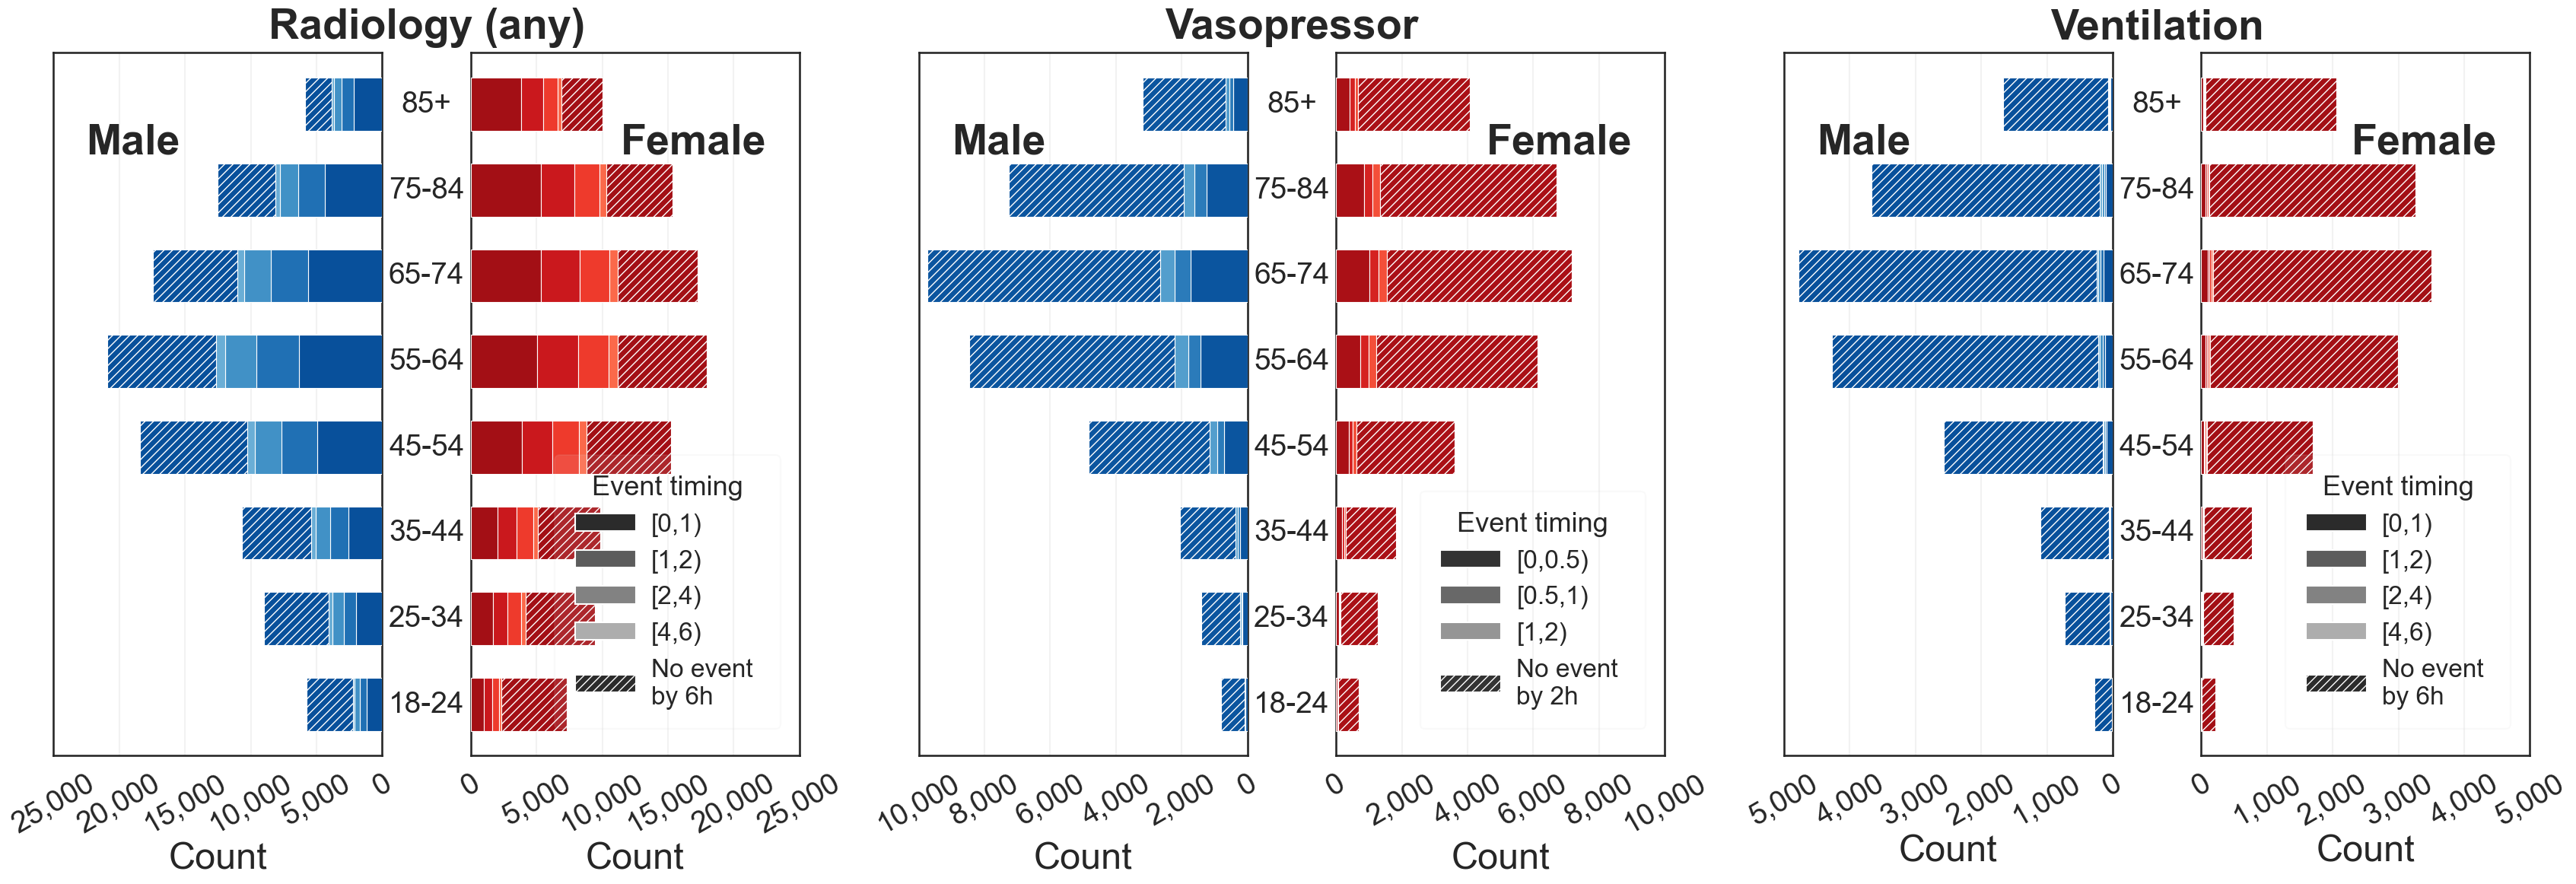

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns


sns.set_theme(style="white", context="talk")


ROOT = Path(".")
PATHS = {
    "Radiology": ROOT / "main" / "shared" / "radiology" / "radiology_analytic_imputed.parquet",
    "Ventilator": ROOT / "main" / "shared" / "vent" / "vent_analytic_imputed.parquet",
    "Vasopressor": ROOT / "main" / "shared" / "pressor" / "pressor_analytic_imputed.parquet",
}

TIME_CONFIG = {
    "Radiology": {
        "time_col": "time_to_any_rad_hours",
        "bins": [0.0, 1.0, 2.0, 4.0, 6.0],
        "labels": ["[0,1)", "[1,2)", "[2,4)", "[4,6)"],
        "no_event_label": "No event \nby 6h",
    },
    "Ventilator": {
        "time_col": "time_to_vent_hours",
        "bins": [0.0, 1.0, 2.0, 4.0, 6.0],
        "labels": ["[0,1)", "[1,2)", "[2,4)", "[4,6)"],
        "no_event_label": "No event \nby 6h",
    },
    "Vasopressor": {
        "time_col": "time_to_pressor_hours",
        "bins": [0.0, 0.5, 1.0, 2.0],
        "labels": ["[0,0.5)", "[0.5,1)", "[1,2)"],
        "no_event_label": "No event \nby 2h",
    },
}

AGE_BINS = [18, 25, 35, 45, 55, 65, 75, 85, 200]
AGE_LABELS = ["18-24", "25-34", "35-44", "45-54", "55-64", "65-74", "75-84", "85+"]

TITLE_FS = 40
LABEL_FS = 26
TICK_FS = 28
LEGEND_TITLE_FS = 26
LEGEND_FS = 24


def _to_str(s):
    return s.astype("string").str.strip()


def collapse_gender(s):
    s = _to_str(s)
    x = s.str.upper()
    out = pd.Series("Other/Unknown", index=s.index, dtype="string")
    out = out.mask(x.str.startswith("M", na=False), "M")
    out = out.mask(x.str.startswith("F", na=False), "F")
    return out


def prepare_demo(path, time_col, bin_edges, bin_labels, no_event_label):
    df = pd.read_parquet(path)[["anchor_age", "gender", time_col]].copy()

    df["anchor_age"] = pd.to_numeric(df["anchor_age"], errors="coerce")
    df[time_col] = pd.to_numeric(df[time_col], errors="coerce")

    df = df[df["anchor_age"].notna()].copy()
    df = df[df["anchor_age"] >= 18].copy()

    df["gender"] = collapse_gender(df["gender"])

    df["age_group"] = pd.cut(
        df["anchor_age"],
        bins=AGE_BINS,
        labels=AGE_LABELS,
        right=False,
        include_lowest=True,
    )
    df = df[df["age_group"].notna()].copy()
    df["age_group"] = pd.Categorical(df["age_group"], categories=AGE_LABELS, ordered=True)
    df = df[df["gender"].isin(["M", "F"])].copy()

    df["time_bin"] = no_event_label

    valid_event = df[time_col].notna() & (df[time_col] >= 0)
    df.loc[valid_event, "time_bin"] = pd.cut(
        df.loc[valid_event, time_col],
        bins=bin_edges,
        labels=bin_labels,
        right=False,
        include_lowest=True,
    ).astype("string")

    df["time_bin"] = df["time_bin"].astype("string")
    df["time_bin"] = df["time_bin"].fillna(no_event_label)

    category_order = list(bin_labels) + [no_event_label]
    df["time_bin"] = pd.Categorical(df["time_bin"], categories=category_order, ordered=True)

    return df


def get_count_matrix(df, group_col, categories):
    out = (
        df.groupby(["gender", "age_group", group_col], observed=False)
        .size()
        .rename("n")
        .reset_index()
    )

    idx = pd.MultiIndex.from_product(
        [["M", "F"], AGE_LABELS, categories],
        names=["gender", "age_group", group_col],
    )

    out = (
        out.set_index(["gender", "age_group", group_col])
        .reindex(idx, fill_value=0)
        .reset_index()
    )
    return out


def make_time_styles(categories, no_event_label):
    male_palette = sns.color_palette("Blues", n_colors=len(categories) + 2).as_hex()
    female_palette = sns.color_palette("Reds", n_colors=len(categories) + 2).as_hex()

    event_categories = [c for c in categories if c != no_event_label]

    male_event_colors = male_palette[-len(event_categories):][::-1]
    female_event_colors = female_palette[-len(event_categories):][::-1]

    male_styles = {}
    female_styles = {}

    for i, cat in enumerate(event_categories):
        male_styles[cat] = {"facecolor": male_event_colors[i], "hatch": None}
        female_styles[cat] = {"facecolor": female_event_colors[i], "hatch": None}

    male_styles[no_event_label] = {
        "facecolor": male_styles[event_categories[0]]["facecolor"],
        "hatch": "///",
    }
    female_styles[no_event_label] = {
        "facecolor": female_styles[event_categories[0]]["facecolor"],
        "hatch": "///",
    }

    return male_styles, female_styles


def make_gray_legend_handles(categories, no_event_label):
    event_categories = [c for c in categories if c != no_event_label]

    gray_levels = sns.color_palette("Greys", n_colors=len(event_categories) + 2).as_hex()
    gray_levels = gray_levels[-len(event_categories):][::-1]

    legend_handles = []

    for i, cat in enumerate(event_categories):
        legend_handles.append(
            Patch(
                facecolor=gray_levels[i],
                edgecolor="white",
                label=cat,
            )
        )

    legend_handles.append(
        Patch(
            facecolor=gray_levels[0],
            edgecolor="white",
            hatch="///",
            label=no_event_label,
        )
    )

    return legend_handles


def draw_stacked_barh(ax, counts_sub, categories, group_col, styles, y_pos, height):
    cum = np.zeros(len(AGE_LABELS), dtype=float)

    for cat in categories:
        vals = (
            counts_sub[counts_sub[group_col] == cat]
            .set_index("age_group")
            .reindex(AGE_LABELS)["n"]
            .to_numpy(dtype=float)
        )

        style = styles[cat]

        ax.barh(
            y=y_pos,
            width=vals,
            left=cum,
            height=height,
            color=style["facecolor"],
            hatch=style["hatch"],
            edgecolor="white",
            linewidth=0.8,
            zorder=3,
        )
        cum += vals


def plot_population_pyramid_panel(fig, outer_spec, df, title, categories, no_event_label):
    counts = get_count_matrix(df, "time_bin", categories)

    total_counts = (
        df.groupby(["gender", "age_group"], observed=False)
        .size()
        .rename("n")
        .reset_index()
    )
    max_count = int(total_counts["n"].max())
    xlim = int(np.ceil(max_count / 250.0) * 250)

    male_styles, female_styles = make_time_styles(categories, no_event_label)

    subgs = outer_spec.subgridspec(
        1, 3,
        width_ratios=[1.0, 0.24, 1.0],
        wspace=0.02,
    )

    ax_left = fig.add_subplot(subgs[0, 0])
    ax_mid = fig.add_subplot(subgs[0, 1], sharey=ax_left)
    ax_right = fig.add_subplot(subgs[0, 2], sharey=ax_left)

    y = np.arange(len(AGE_LABELS))
    bar_h = 0.62

    counts_left = counts[counts["gender"] == "M"]
    counts_right = counts[counts["gender"] == "F"]

    draw_stacked_barh(ax_left, counts_left, categories, "time_bin", male_styles, y, bar_h)
    draw_stacked_barh(ax_right, counts_right, categories, "time_bin", female_styles, y, bar_h)

    ax_left.set_xlim(xlim, 0)
    ax_right.set_xlim(0, xlim)

    ax_left.set_ylim(-0.6, len(AGE_LABELS) - 0.4)
    ax_right.set_ylim(-0.6, len(AGE_LABELS) - 0.4)

    ax_left.set_yticks(y)
    ax_right.set_yticks(y)
    ax_left.set_yticklabels([])
    ax_right.set_yticklabels([])

    ax_mid.set_xlim(0, 1)
    ax_mid.set_xticks([])
    ax_mid.set_yticks([])
    for spine in ax_mid.spines.values():
        spine.set_visible(False)

    for i, label in enumerate(AGE_LABELS):
        ax_mid.text(0.5, i, label, ha="center", va="center", fontsize=TICK_FS)

    left_ticks = ax_left.get_xticks()
    right_ticks = ax_right.get_xticks()

    ax_left.set_xticks(left_ticks)
    ax_right.set_xticks(right_ticks)

    ax_left.set_xticklabels([f"{int(t):,}" for t in left_ticks], fontsize=TICK_FS, rotation=30)
    ax_right.set_xticklabels([f"{int(t):,}" for t in right_ticks], fontsize=TICK_FS, rotation=30)

    ax_left.tick_params(axis="x", labelsize=TICK_FS)
    ax_right.tick_params(axis="x", labelsize=TICK_FS)
    ax_left.tick_params(axis="y", labelsize=TICK_FS, length=0)
    ax_right.tick_params(axis="y", labelsize=TICK_FS, length=0)

    ax_left.grid(axis="x", alpha=0.25, zorder=1)
    ax_right.grid(axis="x", alpha=0.25, zorder=1)
    ax_left.grid(axis="y", visible=False)
    ax_right.grid(axis="y", visible=False)

    ax_left.set_xlabel("Count", fontsize=35)
    ax_right.set_xlabel("Count", fontsize=35)

    ax_left.text(
        0.10, 0.90, "Male",
        transform=ax_left.transAxes,
        ha="left",
        va="top",
        fontsize=TITLE_FS,
        weight="bold",
    )
    ax_right.text(
        0.90, 0.90, "Female",
        transform=ax_right.transAxes,
        ha="right",
        va="top",
        fontsize=TITLE_FS,
        weight="bold",
    )

    ax_mid.set_title(title, fontsize=TITLE_FS, weight="bold", pad=14)

    legend_handles = make_gray_legend_handles(categories, no_event_label)

    ax_right.legend(
        handles=legend_handles,
        loc="lower right",
        bbox_to_anchor=(0.98, 0.02),
        frameon=True,
        fancybox=True,
        framealpha=0.1,
        title="Event timing",
        title_fontsize=LEGEND_TITLE_FS,
        fontsize=LEGEND_FS,
        handlelength=2.4,
        handletextpad=0.6,
        borderpad=0.8,
        labelspacing=0.5,
    )


radiology_cfg = TIME_CONFIG["Radiology"]
ventilator_cfg = TIME_CONFIG["Ventilator"]
vasopressor_cfg = TIME_CONFIG["Vasopressor"]

radiology = prepare_demo(
    PATHS["Radiology"],
    radiology_cfg["time_col"],
    radiology_cfg["bins"],
    radiology_cfg["labels"],
    radiology_cfg["no_event_label"],
)

vasopressor = prepare_demo(
    PATHS["Vasopressor"],
    vasopressor_cfg["time_col"],
    vasopressor_cfg["bins"],
    vasopressor_cfg["labels"],
    vasopressor_cfg["no_event_label"],
)

ventilator = prepare_demo(
    PATHS["Ventilator"],
    ventilator_cfg["time_col"],
    ventilator_cfg["bins"],
    ventilator_cfg["labels"],
    ventilator_cfg["no_event_label"],
)



fig = plt.figure(figsize=(42, 12))
outer = fig.add_gridspec(1, 3, wspace=0.16)

panels = [
    (radiology, "Radiology (any)", radiology_cfg),
    (vasopressor, "Vasopressor", vasopressor_cfg),
    (ventilator, "Ventilation", ventilator_cfg),
]

for i, (data, title, cfg) in enumerate(panels):
    plot_population_pyramid_panel(
        fig,
        outer[0, i],
        data,
        title,
        cfg["labels"] + [cfg["no_event_label"]],
        cfg["no_event_label"],
    )



plt.savefig("./figures/population_pyramid.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [3]:
for name, data, cfg in [
    ("Radiology", radiology, radiology_cfg),
    ("Vasopressor", vasopressor, vasopressor_cfg),
    ("Ventilation", ventilator, ventilator_cfg),
]:
    categories = cfg["labels"] + [cfg["no_event_label"]]
    counts = get_count_matrix(data, "time_bin", categories).copy()

    for gender in ["M", "F"]:
        mat = (
            counts[counts["gender"] == gender]
            .pivot(index="age_group", columns="time_bin", values="n")
            .reindex(index=AGE_LABELS, columns=categories)
        )

        print(f"\n=== {name} | {gender} ===")
        print(
            mat.to_string(
                float_format=lambda x: f"{x:.0f}"
            )
        )


=== Radiology | M ===
time_bin   [0,1)  [1,2)  [2,4)  [4,6)  No event \nby 6h
age_group                                              
18-24       1199    494    389    110              3578
25-34       1962    971    878    288              4902
35-44       2582   1353   1111    341              5283
45-54       4950   2690   2045    595              8166
55-64       6351   3219   2367    698              8307
65-74       5611   2859   2010    558              6407
75-84       4376   1987   1388    365              4424
85+         2190    900    598    148              2012

=== Radiology | F ===
time_bin   [0,1)  [1,2)  [2,4)  [4,6)  No event \nby 6h
age_group                                              
18-24       1006    605    560    172              4982
25-34       1665   1100   1064    364              5243
35-44       2007   1478   1242    376              4716
45-54       3871   2345   2029    564              6416
55-64       5046   3131   2332    668              6760
65

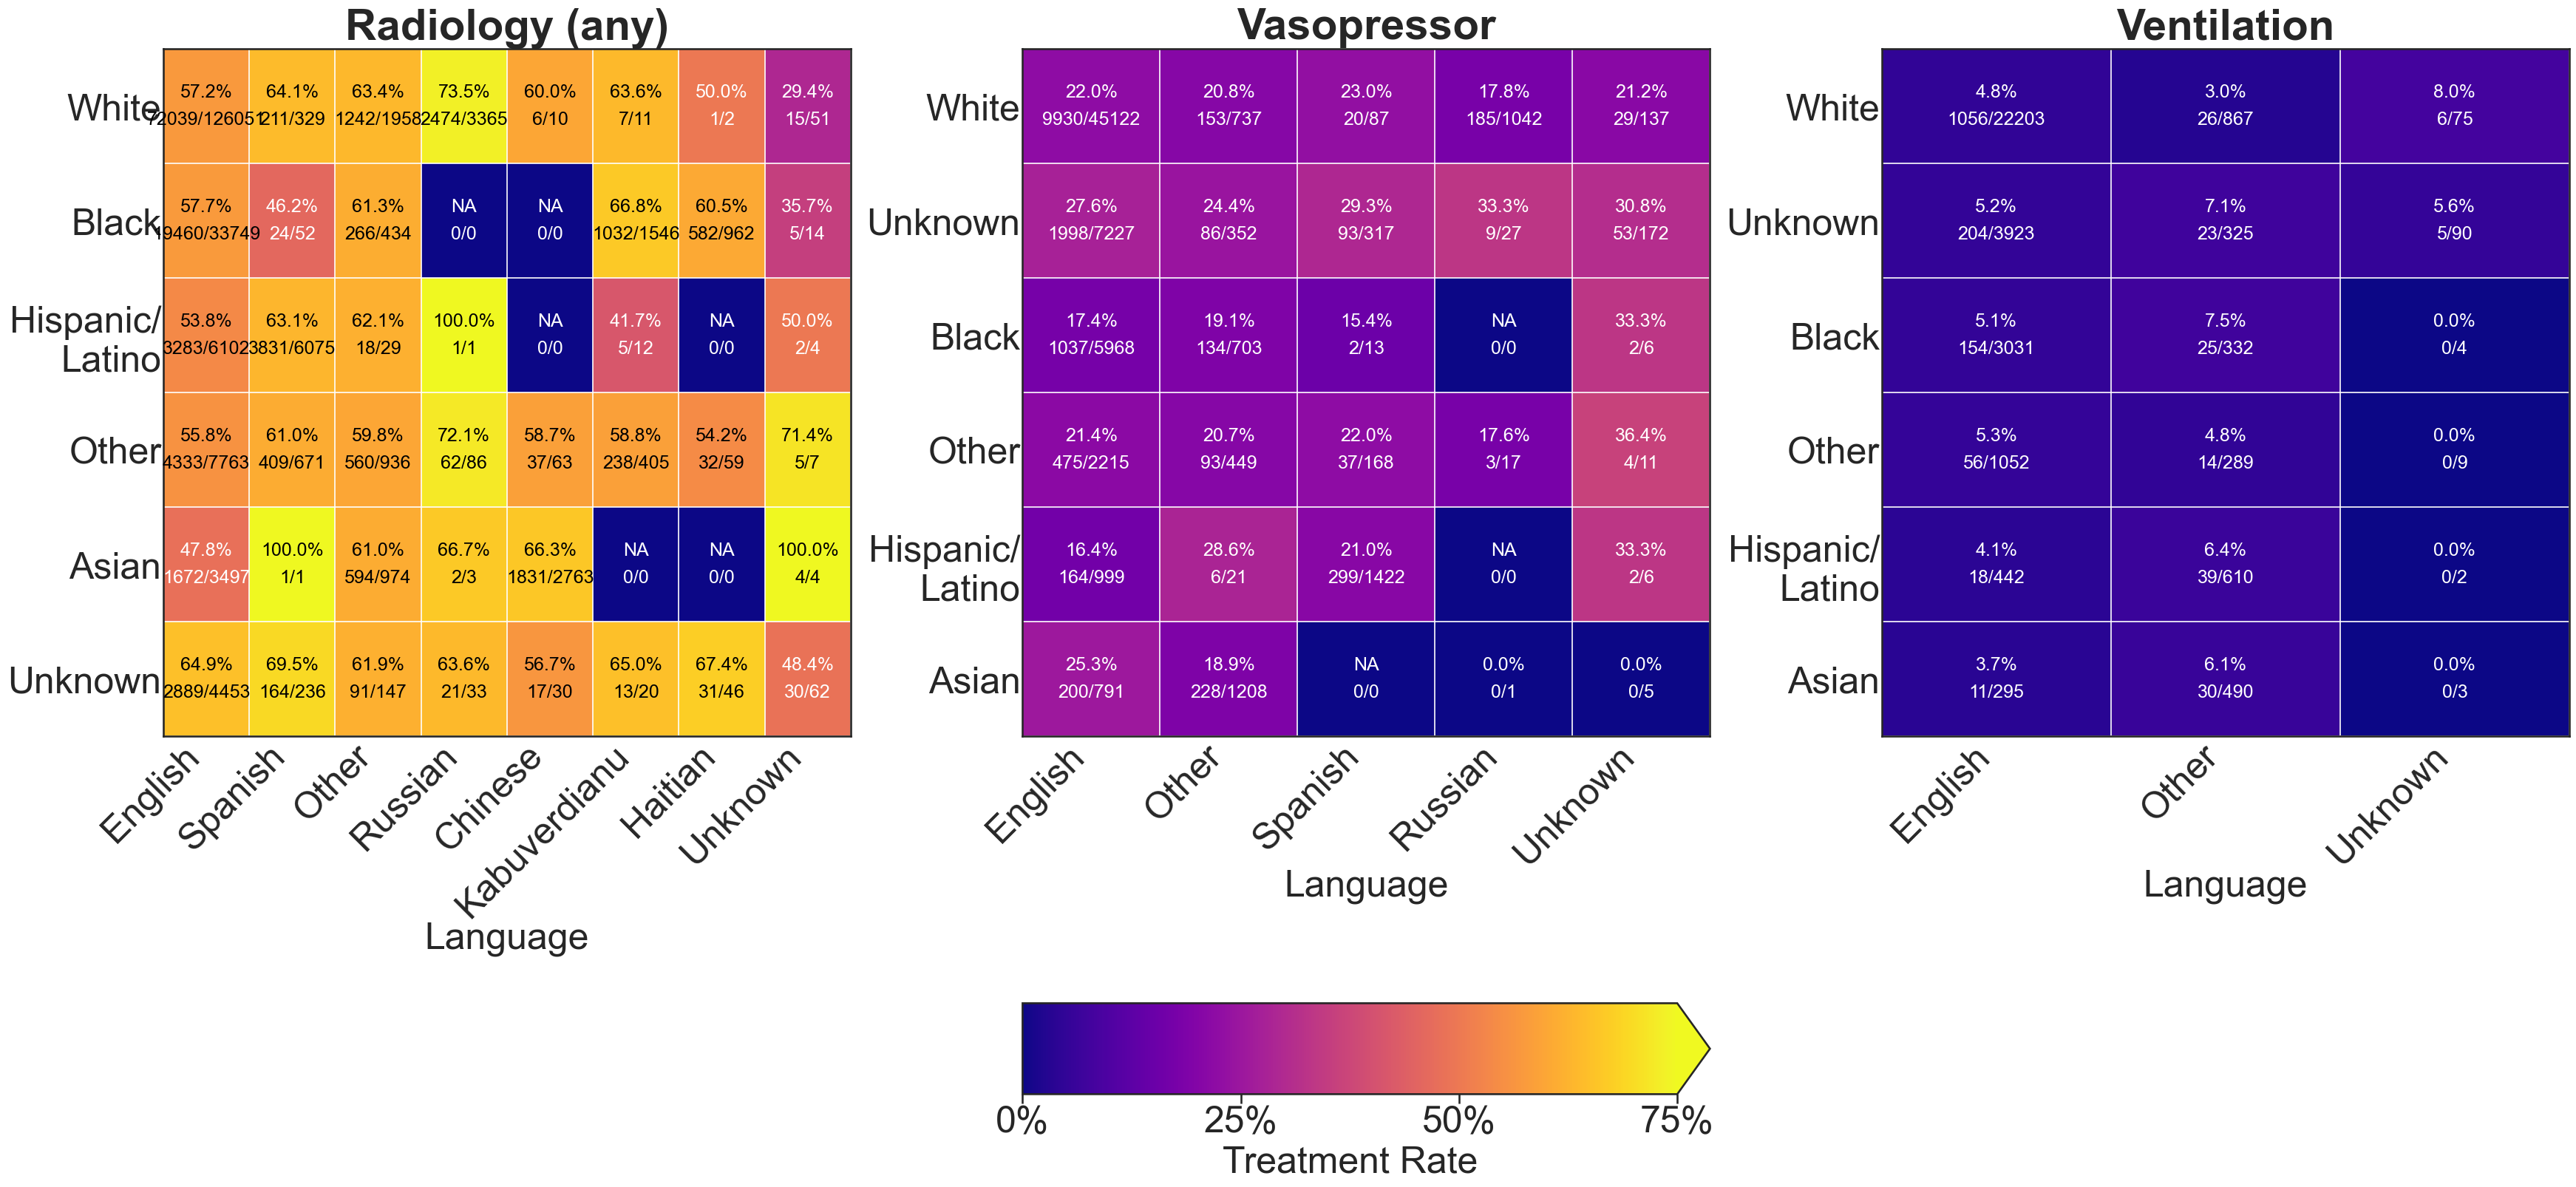

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

TITLE_FS = 42
LABEL_FS = 36
TICK_FS = 36
TEXT_FS = 18
CBAR_FS = 38
FIG_W = 42
FIG_H = 17
PANEL_WSPACE = 0.25
RATE_CAP = 0.75

ROOT = Path('.')
MAIN = ROOT / 'main'

PATHS = {
    'Radiology': MAIN / 'shared' / 'radiology' / 'radiology_analytic_imputed.parquet',
    'Vasopressor': MAIN / 'shared' / 'pressor' / 'pressor_analytic_imputed.parquet',
    'Ventilation': MAIN / 'shared' / 'vent' / 'vent_analytic_imputed.parquet',
}

TREATMENT_OUTCOME = {
    'Radiology': 'time_to_any_rad_hours',
    'Vasopressor': 'time_to_pressor_hours',
    'Ventilation': 'time_to_vent_hours',
}

PANEL_TITLES = {
    'Radiology': 'Radiology (any)',
    'Vasopressor': 'Vasopressor',
    'Ventilation': 'Ventilation',
}


def _to_str(s: pd.Series) -> pd.Series:
    return s.astype('string').str.strip()


def collapse_gender(s: pd.Series) -> pd.Series:
    s = _to_str(s)
    x = s.str.upper()
    out = pd.Series('Other/Unknown', index=s.index, dtype='string')
    out = out.mask(x.str.startswith('M', na=False), 'M')
    out = out.mask(x.str.startswith('F', na=False), 'F')
    return out


def display_series(s: pd.Series) -> pd.Series:
    x = _to_str(s)
    x = x.mask(x.isna(), '<NA>')
    x = x.mask(x.eq(''), '<EMPTY>')
    return x


def build_tables(df: pd.DataFrame, treatment_col: str):
    d = df.loc[:, ['race', 'language', 'gender', treatment_col]].copy()
    d['race'] = display_series(d['race'])
    d['language'] = display_series(d['language'])
    d['gender'] = collapse_gender(d['gender'])
    d[treatment_col] = pd.to_numeric(d[treatment_col], errors='coerce')
    d['treated'] = d[treatment_col].notna() & (d[treatment_col] >= 0)
    d = d.loc[d['gender'].isin(['M', 'F'])].copy()

    race_order = (
        d.groupby('race', observed=False)
        .size()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    language_order = (
        d.groupby('language', observed=False)
        .size()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    count_tbl = (
        d.groupby(['race', 'language'], observed=False)
        .size()
        .unstack('language', fill_value=0)
        .reindex(index=race_order, columns=language_order, fill_value=0)
        .astype(int)
    )

    treated_tbl = (
        d.groupby(['race', 'language'], observed=False)['treated']
        .sum()
        .unstack('language', fill_value=0)
        .reindex(index=race_order, columns=language_order, fill_value=0)
        .astype(int)
    )

    rate_tbl = treated_tbl / count_tbl.where(count_tbl > 0)

    return count_tbl, treated_tbl, rate_tbl, race_order, language_order


def relative_luminance(rgba):
    return 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]


def plot_panel(ax, count_tbl, treated_tbl, rate_tbl, race_order, language_order, panel_title, norm):
    mat_raw = rate_tbl.to_numpy(dtype=float)
    mat_display = np.minimum(np.where(np.isnan(mat_raw), 0.0, mat_raw), RATE_CAP)

    im = ax.imshow(
        mat_display,
        cmap='plasma',
        norm=norm,
        interpolation='none',
        aspect='auto',
    )

    ax.set_box_aspect(1)
    ax.set_xticks(np.arange(len(language_order)))
    ax.set_yticks(np.arange(len(race_order)))
    ax.set_xticklabels(language_order, fontsize=TICK_FS, rotation=45, ha='right')

    race_labels = [
        x.replace('Hispanic/Latino', 'Hispanic/\nLatino')
        for x in race_order
    ]

    ax.set_yticklabels(race_labels, fontsize=TICK_FS)
    ax.set_xlabel('Language', fontsize=LABEL_FS, labelpad=-2)
    ax.set_title(panel_title, fontsize=TITLE_FS, pad=10, weight='bold')

    ax.set_xticks(np.arange(-0.5, len(language_order), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(race_order), 1), minor=True)
    ax.grid(which='minor', color='white', linestyle='-', linewidth=1.2)
    ax.tick_params(which='minor', bottom=False, left=False)
    ax.tick_params(axis='x', which='major', length=0, labelsize=TICK_FS, pad=2)
    ax.tick_params(axis='y', which='major', length=0, labelsize=TICK_FS, pad=2)

    for i in range(len(race_order)):
        for j in range(len(language_order)):
            n = int(count_tbl.iloc[i, j])
            treated = int(treated_tbl.iloc[i, j])
            rate = rate_tbl.iloc[i, j]

            rgba = im.cmap(norm(mat_display[i, j]))
            txt_color = 'black' if relative_luminance(rgba) > 0.62 else 'white'
            if n == 0:
                txt_color = 'white'

            rate_label = 'NA' if pd.isna(rate) else f'{100 * rate:.1f}%'

            ax.text(
                j,
                i - 0.12,
                rate_label,
                ha='center',
                va='center',
                fontsize=TEXT_FS,
                color=txt_color,
                zorder=6,
            )

            ax.text(
                j,
                i + 0.12,
                f'{treated}/{n}',
                ha='center',
                va='center',
                fontsize=TEXT_FS,
                color=txt_color,
                zorder=6,
            )

    return im


cohorts = {name: pd.read_parquet(path) for name, path in PATHS.items()}

panel_tables = {
    cohort_name: build_tables(df, TREATMENT_OUTCOME[cohort_name])
    for cohort_name, df in cohorts.items()
}

norm = Normalize(vmin=0.0, vmax=RATE_CAP)

fig = plt.figure(figsize=(FIG_W, FIG_H))
outer = fig.add_gridspec(
    2,
    3,
    height_ratios=[1.0, 0.12],
    hspace=0.28,
    wspace=PANEL_WSPACE,
)

axes = [fig.add_subplot(outer[0, i]) for i in range(3)]
cax = fig.add_subplot(outer[1, 1])

pos = cax.get_position()
cax.set_position([
    pos.x0,
    pos.y0 - 0.09,
    pos.width,
    pos.height,
])

for ax, cohort_name in zip(axes, ['Radiology', 'Vasopressor', 'Ventilation']):
    count_tbl, treated_tbl, rate_tbl, race_order, language_order = panel_tables[cohort_name]
    plot_panel(
        ax=ax,
        count_tbl=count_tbl,
        treated_tbl=treated_tbl,
        rate_tbl=rate_tbl,
        race_order=race_order,
        language_order=language_order,
        panel_title=PANEL_TITLES[cohort_name],
        norm=norm,
    )

sm = plt.cm.ScalarMappable(norm=norm, cmap='plasma')
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax, orientation='horizontal', extend='max')
ticks = np.linspace(0.0, RATE_CAP, 4)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f'{100 * x:.0f}%' for x in ticks])
cbar.set_label('Treatment Rate', fontsize=LABEL_FS, labelpad=6)
cbar.ax.tick_params(axis='x', labelsize=TICK_FS, pad=2)

Path('./figures').mkdir(parents=True, exist_ok=True)
plt.savefig('./figures/demographic_heatmaps.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [5]:
for cohort_name in ["Radiology", "Vasopressor", "Ventilation"]:
    count_tbl, treated_tbl, rate_tbl, race_order, language_order = panel_tables[cohort_name]

    rows = []

    for race in race_order:
        for language in language_order:
            n = int(count_tbl.loc[race, language])
            treated = int(treated_tbl.loc[race, language])
            rate = rate_tbl.loc[race, language]

            rows.append({
                "cohort": cohort_name,
                "race": race,
                "language": language,
                "treated": treated,
                "total": n,
                "treatment_rate": rate,
                "plot_label_rate": "NA" if pd.isna(rate) else f"{100 * rate:.1f}%",
                "plot_label_count": f"{treated}/{n}",
            })

    table = pd.DataFrame(rows)

    print(f"\n=== {cohort_name}: plotted cell labels ===")
    print(
        table.to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )


=== Radiology: plotted cell labels ===
   cohort            race     language  treated  total  treatment_rate plot_label_rate plot_label_count
Radiology           White      English    72039 126051          0.5715           57.2%     72039/126051
Radiology           White      Spanish      211    329          0.6413           64.1%          211/329
Radiology           White        Other     1242   1958          0.6343           63.4%        1242/1958
Radiology           White      Russian     2474   3365          0.7352           73.5%        2474/3365
Radiology           White      Chinese        6     10          0.6000           60.0%             6/10
Radiology           White Kabuverdianu        7     11          0.6364           63.6%             7/11
Radiology           White      Haitian        1      2          0.5000           50.0%              1/2
Radiology           White      Unknown       15     51          0.2941           29.4%            15/51
Radiology           Blac

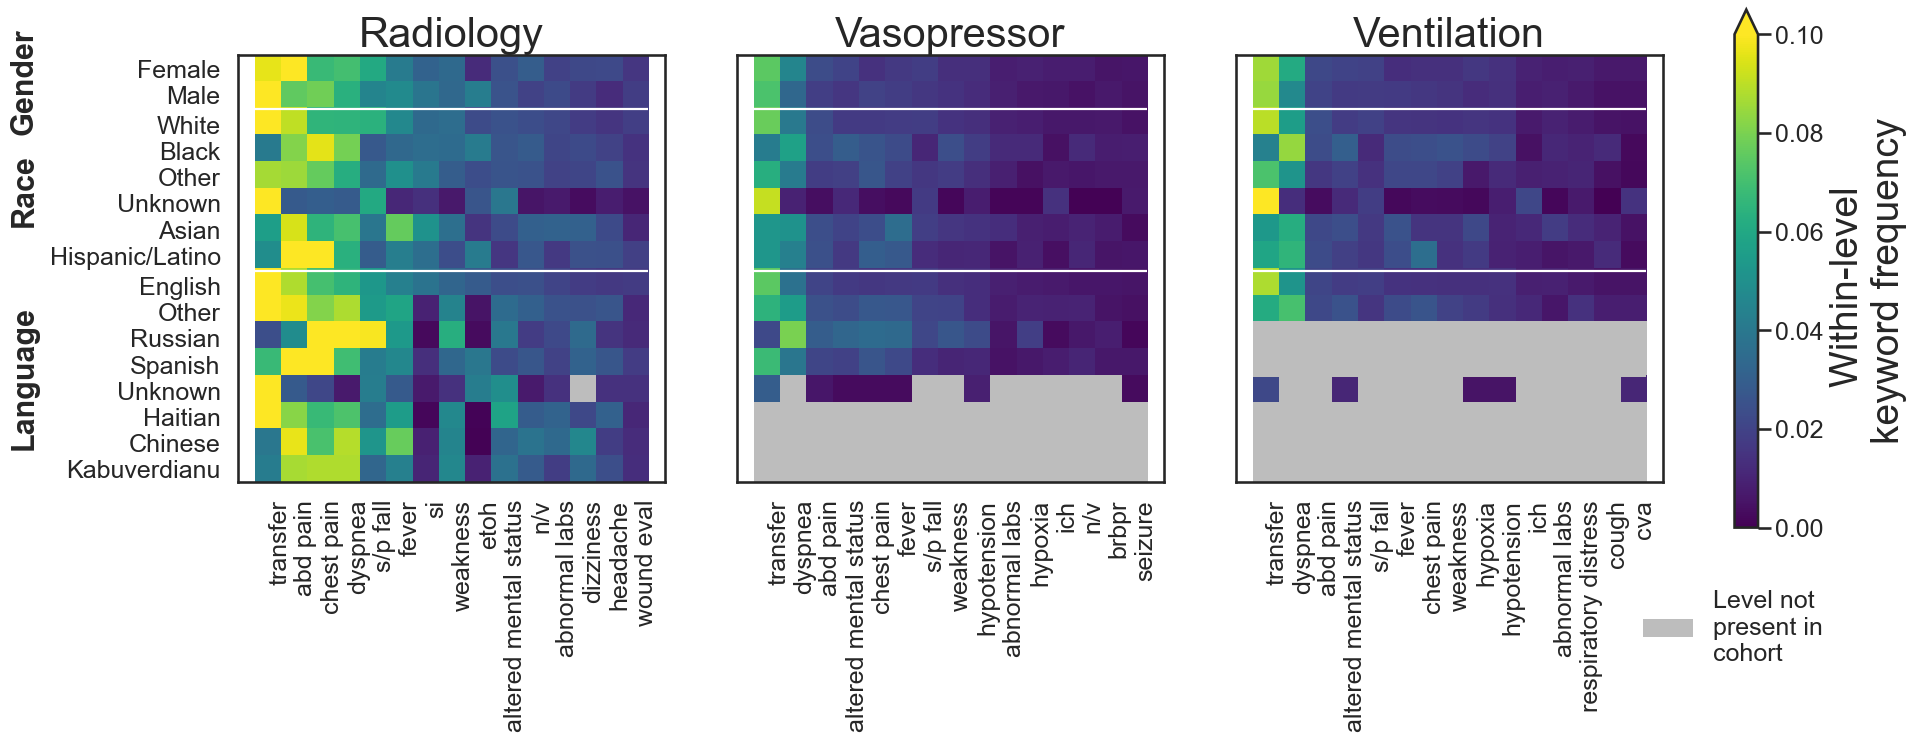

In [6]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


TITLE_FS = 30
TICK_FS = 18
GROUP_FS = 22

ROOT = Path(".")
MAIN = ROOT / "main"

COHORT_PATHS = {
    "Radiology": MAIN / "shared" / "radiology" / "radiology_analytic_imputed.parquet",
    "Pressor": MAIN / "shared" / "pressor" / "pressor_analytic_imputed.parquet",
    "Vent": MAIN / "shared" / "vent" / "vent_analytic_imputed.parquet",
}

DISPLAY_NAME = {
    "Radiology": "Radiology",
    "Pressor": "Vasopressor",
    "Vent": "Ventilation",
}

TEXT_COL = "chiefcomplaint"
DEMO_VARS = ["gender", "race", "language"]
TOP_K = 15
VMAX = 0.10
GROUP_GAP = 0.15

GROUP_TITLE_MAP = {
    "gender": "Gender",
    "race": "Race",
    "language": "Language",
}

OUTPUT_DIR = Path("./figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def clean_token(x: str) -> str:
    x = str(x).lower().strip()
    x = re.sub(r"\s+", " ", x)
    return x


def split_cc_tokens(series: pd.Series) -> pd.Series:
    s = series.astype("string")
    s = s.where(s.notna(), "")
    s = s.str.split(",")

    out = []
    for items in s.tolist():
        if items is pd.NA or items is None:
            out.append([])
            continue

        toks = []
        for item in items:
            tok = clean_token(item)
            if tok != "" and tok != "no_cc":
                toks.append(tok)

        out.append(sorted(set(toks)))

    return pd.Series(out, index=series.index, dtype="object")


def normalize_demo(series: pd.Series, var: str) -> pd.Series:
    s = series.astype("string")
    s = s.where(s.notna(), "Unknown")
    s = s.str.strip()
    s = s.where(s != "", "Unknown")
    s = s.astype(str)

    if var == "gender":
        gender_map = {
            "F": "Female",
            "M": "Male",
            "Female": "Female",
            "Male": "Male",
            "f": "Female",
            "m": "Male",
            "female": "Female",
            "male": "Male",
        }
        s = s.map(lambda x: gender_map.get(x, x))

    return s


def build_token_long(df: pd.DataFrame, text_col: str) -> pd.DataFrame:
    token_lists = split_cc_tokens(df[text_col])

    row_id = np.repeat(np.arange(len(df)), token_lists.map(len).to_numpy())
    token = [tok for toks in token_lists.tolist() for tok in toks]

    return pd.DataFrame(
        {
            "row_id": row_id,
            "token": token,
        }
    )


def compute_top_tokens(token_long: pd.DataFrame, top_k: int) -> list[str]:
    token_top = (
        token_long.groupby("token", as_index=False)
        .agg(freq=("row_id", "nunique"))
        .sort_values(["freq", "token"], ascending=[False, True])
        .head(top_k)
        .reset_index(drop=True)
    )
    return token_top["token"].tolist()


def collect_union_levels(all_dfs: dict[str, pd.DataFrame], demo_vars: list[str]) -> dict[str, list[str]]:
    union_levels = {}

    for group_var in demo_vars:
        first_seen = []
        seen = set()

        for cohort_name in ["Radiology", "Pressor", "Vent"]:
            df = all_dfs[cohort_name]
            s = normalize_demo(df[group_var], group_var)

            for val in s.tolist():
                if val not in seen:
                    seen.add(val)
                    first_seen.append(val)

        union_levels[group_var] = first_seen

    return union_levels


def build_master_row_spec(union_levels: dict[str, list[str]]) -> pd.DataFrame:
    rows = []

    for group_var in DEMO_VARS:
        for level in union_levels[group_var]:
            rows.append(
                {
                    "group_var": group_var,
                    "level": level,
                    "row_id": f"{group_var}::{level}",
                    "row_label": level,
                }
            )

    return pd.DataFrame(rows)


def compute_y_positions(row_spec: pd.DataFrame, gap: float) -> np.ndarray:
    y = []
    current = 0.0
    prev_group = None

    for _, row in row_spec.iterrows():
        if prev_group is not None and row["group_var"] != prev_group:
            current += gap
        y.append(current)
        current += 1.0
        prev_group = row["group_var"]

    return np.array(y, dtype=float)


def build_combined_heatmap_matrix(
    df: pd.DataFrame,
    token_long: pd.DataFrame,
    top_tokens: list[str],
    row_spec: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.Series]:
    present_rows = []

    for group_var in DEMO_VARS:
        demo = normalize_demo(df[group_var], group_var)
        present_levels = set(demo.unique().tolist())

        group_rows = row_spec.loc[row_spec["group_var"] == group_var, ["group_var", "level", "row_id"]].copy()
        group_rows["present"] = group_rows["level"].isin(present_levels)
        present_rows.append(group_rows[["row_id", "present"]])

    present_map = pd.concat(present_rows, ignore_index=True).set_index("row_id")["present"]

    level_size_rows = []
    obs_rows = []

    for group_var in DEMO_VARS:
        demo = normalize_demo(df[group_var], group_var)

        level_sizes = (
            demo.value_counts()
            .rename_axis("level")
            .reset_index(name="n_level")
        )
        level_sizes["group_var"] = group_var
        level_size_rows.append(level_sizes)

        tmp = token_long.loc[token_long["token"].isin(top_tokens)].copy()
        tmp["level"] = demo.iloc[tmp["row_id"]].to_numpy()
        tmp["group_var"] = group_var

        obs = (
            tmp.groupby(["group_var", "level", "token"], as_index=False)
            .agg(n_obs=("row_id", "nunique"))
        )
        obs_rows.append(obs)

    level_sizes = pd.concat(level_size_rows, ignore_index=True)
    obs = pd.concat(obs_rows, ignore_index=True)

    full_grid = (
        row_spec[["group_var", "level", "row_id"]]
        .merge(pd.DataFrame({"token": top_tokens}), how="cross")
    )

    mat_long = (
        full_grid
        .merge(obs, on=["group_var", "level", "token"], how="left")
        .merge(level_sizes, on=["group_var", "level"], how="left")
    )

    mat_long["freq"] = mat_long["n_obs"] / mat_long["n_level"]

    mat = mat_long.pivot(index="row_id", columns="token", values="freq")
    mat = mat.reindex(index=row_spec["row_id"].tolist(), columns=top_tokens)

    present_map = present_map.reindex(row_spec["row_id"].tolist())

    return mat, present_map


def get_group_centers(row_spec: pd.DataFrame, y_pos: np.ndarray) -> list[tuple[str, float]]:
    out = []
    for group_var in DEMO_VARS:
        idx = np.where(row_spec["group_var"].to_numpy() == group_var)[0]
        out.append((GROUP_TITLE_MAP[group_var], y_pos[idx].mean()))
    return out


def draw_group_labels(ax, row_spec: pd.DataFrame, y_pos: np.ndarray):
    centers = get_group_centers(row_spec, y_pos)

    for label, y in centers:
        ax.text(
            -0.50,
            y,
            label,
            transform=ax.get_yaxis_transform(),
            ha="center",
            va="center",
            rotation=90,
            fontsize=GROUP_FS,
            fontweight="bold",
        )


def draw_group_separators(ax, row_spec: pd.DataFrame, y_pos: np.ndarray, ncols: int):
    for i in range(len(row_spec) - 1):
        g0 = row_spec.iloc[i]["group_var"]
        g1 = row_spec.iloc[i + 1]["group_var"]
        if g0 != g1:
            y_sep = 0.5 * (y_pos[i] + y_pos[i + 1])
            ax.hlines(
                y=y_sep,
                xmin=-0.5,
                xmax=ncols - 0.5,
                colors="white",
                linewidth=1.6,
                zorder=5,
            )


def draw_missing_blocks(ax, mat: pd.DataFrame, present_map: pd.Series, y_pos: np.ndarray):
    missing_rows = np.where(~present_map.to_numpy(dtype=bool))[0]

    for i in missing_rows:
        y0 = y_pos[i] - 0.5
        rect = Rectangle(
            (-0.5, y0),
            width=mat.shape[1],
            height=1.0,
            facecolor="#bdbdbd",
            edgecolor="none",
            zorder=2.2,
        )
        ax.add_patch(rect)


def draw_one_heatmap(
    ax,
    mat: pd.DataFrame,
    row_spec: pd.DataFrame,
    present_map: pd.Series,
    y_pos: np.ndarray,
    title: str,
):
    arr = mat.to_numpy(dtype=float)
    masked = np.ma.masked_invalid(arr)

    cmap = plt.colormaps["viridis"].copy()
    cmap.set_bad(color="#bdbdbd")

    im = ax.imshow(
        masked,
        aspect="equal",
        interpolation="nearest",
        cmap=cmap,
        vmin=0.0,
        vmax=VMAX,
        extent=[-0.5, mat.shape[1] - 0.5, y_pos[-1] + 0.5, y_pos[0] - 0.5],
        zorder=2,
    )

    draw_missing_blocks(ax, mat, present_map, y_pos)

    ax.set_box_aspect(1)
    ax.set_title(title, fontsize=TITLE_FS)

    ax.set_xticks(np.arange(mat.shape[1]))
    ax.set_xticklabels(
        mat.columns.tolist(),
        rotation=90,
        ha="right",
        rotation_mode="anchor",
        fontsize=TICK_FS,
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(row_spec["row_label"].tolist(), fontsize=TICK_FS)

    ax.set_xlabel("")

    ax.set_xticks(np.arange(-0.5, mat.shape[1], 1), minor=True)

    y_minor = []
    for y in y_pos:
        y_minor.extend([y - 0.5, y + 0.5])
    ax.set_yticks(y_minor, minor=True)

    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.0)
    ax.tick_params(which="minor", bottom=False, left=False)

    draw_group_separators(ax, row_spec, y_pos, mat.shape[1])

    return im


all_dfs = {}
for cohort_name, path in COHORT_PATHS.items():
    all_dfs[cohort_name] = pd.read_parquet(path)

union_levels = collect_union_levels(all_dfs, DEMO_VARS)
master_row_spec = build_master_row_spec(union_levels)
shared_y_pos = compute_y_positions(master_row_spec, gap=GROUP_GAP)

results = {}

for cohort_name in ["Radiology", "Pressor", "Vent"]:
    df = all_dfs[cohort_name]
    token_long = build_token_long(df, TEXT_COL)
    top_tokens = compute_top_tokens(token_long, TOP_K)

    mat, present_map = build_combined_heatmap_matrix(
        df=df,
        token_long=token_long,
        top_tokens=top_tokens,
        row_spec=master_row_spec,
    )

    results[cohort_name] = {
        "matrix": mat,
        "present_map": present_map,
    }

fig = plt.figure(figsize=(19, 7))
gs = fig.add_gridspec(
    1,
    4,
    width_ratios=[1, 1, 1, 0.055],
    left=0.17,
    right=0.97,
    bottom=0.18,
    top=0.92,
    wspace=0.22,
)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
]
cax = fig.add_subplot(gs[0, 3])

last_im = None
for ax, cohort_name in zip(axes, ["Radiology", "Pressor", "Vent"]):
    last_im = draw_one_heatmap(
        ax=ax,
        mat=results[cohort_name]["matrix"],
        row_spec=master_row_spec,
        present_map=results[cohort_name]["present_map"],
        y_pos=shared_y_pos,
        title=DISPLAY_NAME[cohort_name],
    )

draw_group_labels(axes[0], master_row_spec, shared_y_pos)

for ax in axes[1:]:
    ax.set_yticks(shared_y_pos)
    ax.tick_params(axis="y", labelleft=False)
    ax.set_ylim(axes[0].get_ylim())

cbar = fig.colorbar(last_im, cax=cax, extend="max")
cbar.set_label("Within-level \nkeyword frequency", fontsize=TITLE_FS - 2)
cbar.ax.tick_params(labelsize=TICK_FS)

from matplotlib.patches import Patch

gray_patch = Patch(
    facecolor="#bdbdbd",
    edgecolor="none",
    label="Level not \npresent in \ncohort"
)

# put legend directly under colorbar
cax.legend(
    handles=[gray_patch],
    loc="upper center",
    bbox_to_anchor=(0.1, -0.08),  # control vertical spacing
    fontsize=TICK_FS,
    frameon=False,
)

plt.savefig(
    OUTPUT_DIR / "combined_keyword_heatmap.pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.show()

In [7]:
for cohort_name in ["Radiology", "Pressor", "Vent"]:
    mat = results[cohort_name]["matrix"].copy()
    present_map = results[cohort_name]["present_map"]

    mat.index = mat.index.map(lambda x: x.split("::")[1])

    table = mat.copy()
    table["present"] = present_map.values

    print(f"\n=== {cohort_name} ===")
    print(
        table.to_string(
            float_format=lambda x: f"{x:.4f}"
        )
    )


=== Radiology ===
token            transfer  abd pain  chest pain  dyspnea  s/p fall  fever     si  weakness   etoh  altered mental status    n/v  abnormal labs  dizziness  headache  wound eval  present
row_id                                                                                                                                                                                  
Female             0.0961    0.1010      0.0677   0.0700    0.0607 0.0415 0.0316    0.0342 0.0124                 0.0245 0.0297         0.0193     0.0215    0.0220      0.0160     True
Male               0.1035    0.0754      0.0784   0.0635    0.0450 0.0477 0.0387    0.0337 0.0425                 0.0255 0.0197         0.0223     0.0173    0.0126      0.0181     True
White              0.1171    0.0905      0.0655   0.0652    0.0639 0.0469 0.0343    0.0359 0.0230                 0.0250 0.0238         0.0212     0.0179    0.0155      0.0185     True
Black              0.0411    0.0816      0.0960   0.0793

## Main weighted DAGJ outcome plot

In [8]:
from pathlib import Path
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec




group_order = ["gender", "race", "language"]

group_title_map = {
    "gender": "Gender",
    "race": "Race",
    "language": "Language",
}

outcome_map = {
    "time_to_xray_hours": "X-ray",
    "time_to_any_rad_hours": "Any radiology",
    "time_to_advanced_hours": "Advanced imaging",
    "time_to_pressor_hours": "Vasopressor",
    "time_to_vent_hours": "Ventilator",
}

outcome_order = [
    "time_to_xray_hours",
    "time_to_any_rad_hours",
    "time_to_advanced_hours",
    "time_to_pressor_hours",
    "time_to_vent_hours",
]


def pretty_level_name(term, group_var):
    prefix = f"{group_var}_"
    if isinstance(term, str) and term.startswith(prefix):
        val = term[len(prefix):]
    else:
        val = term

    val = str(val).replace("_", " ").strip()

    if group_var == "gender":
        if val == "M":
            return "Male"
        if val == "F":
            return "Female"

    return val.title()






ROOT = Path(".")

RAD_DIR = ROOT / "main" / "radiology" / "delete_a_group_jackknife"
ICU_PRESSOR_DIR = ROOT / "main" / "icu" / "pressor" / "delete_a_group_jackknife"
ICU_VENT_DIR = ROOT / "main" / "icu" / "vent" / "delete_a_group_jackknife"


ESTIMAND_LABEL = "IPSW-weighted fixed-DAGJ estimand"


def load_dagj_pair(base_dir, dataset_name):
    point_compare_path = base_dir / "jackknife_point_compare.parquet"
    compare_path = base_dir / "jackknife_compare.parquet"
    summary_path = base_dir / "jackknife_summary.parquet"

    assert point_compare_path.exists(), (
        f"{point_compare_path} is missing. "
        "Run the revised weighted delete-a-group jackknife script first."
    )

    point_compare = pd.read_parquet(point_compare_path)
    compare = pd.read_parquet(compare_path)
    summary = pd.read_parquet(summary_path)

    point_compare = point_compare.copy()
    compare = compare.copy()
    summary = summary.copy()

    if "dataset" not in point_compare.columns:
        point_compare["dataset"] = dataset_name
    if "dataset" not in compare.columns:
        compare["dataset"] = dataset_name
    if "dataset" not in summary.columns:
        summary["dataset"] = dataset_name

    point_compare["estimand"] = ESTIMAND_LABEL
    compare["estimand"] = ESTIMAND_LABEL
    summary["estimand"] = ESTIMAND_LABEL

    return compare, summary


rad_long, rad_summ = load_dagj_pair(RAD_DIR, "radiology")
pressor_long, pressor_summ = load_dagj_pair(ICU_PRESSOR_DIR, "pressor")
vent_long, vent_summ = load_dagj_pair(ICU_VENT_DIR, "vent")

jackknife_long = pd.concat(
    [rad_long, pressor_long, vent_long],
    ignore_index=True,
)

jackknife_summary = pd.concat(
    [rad_summ, pressor_summ, vent_summ],
    ignore_index=True,
)

required_long_cols = [
    "outcome",
    "group_var",
    "level",
    "ref_level",
    "term",
    "delete_group",
    "delta_beta",
]

required_summ_cols = [
    "outcome",
    "group_var",
    "level",
    "ref_level",
    "term",
    "beta_structured",
    "beta_structured_plus_text",
    "delta_beta",
    "beta_structured_jackknife_ci_low",
    "beta_structured_jackknife_ci_high",
    "beta_structured_plus_text_jackknife_ci_low",
    "beta_structured_plus_text_jackknife_ci_high",
    "delta_beta_jackknife_ci_low",
    "delta_beta_jackknife_ci_high",
]

missing_long = [c for c in required_long_cols if c not in jackknife_long.columns]
missing_summ = [c for c in required_summ_cols if c not in jackknife_summary.columns]

assert len(missing_long) == 0, f"jackknife_compare missing columns: {missing_long}"
assert len(missing_summ) == 0, f"jackknife_summary missing columns: {missing_summ}"
assert "estimand" in jackknife_long.columns and "estimand" in jackknife_summary.columns

plot_long = jackknife_long.copy()
plot_summ = jackknife_summary.copy()

plot_long["delta_disp"] = pd.to_numeric(plot_long["delta_beta"], errors="coerce")

plot_summ["disp_base"] = pd.to_numeric(plot_summ["beta_structured"], errors="coerce")
plot_summ["disp_text"] = pd.to_numeric(plot_summ["beta_structured_plus_text"], errors="coerce")
plot_summ["delta_disp"] = pd.to_numeric(plot_summ["delta_beta"], errors="coerce")
plot_summ["abs_delta_disp"] = np.abs(plot_summ["delta_disp"])

plot_summ["base_lo"] = pd.to_numeric(plot_summ["beta_structured_jackknife_ci_low"], errors="coerce")
plot_summ["base_hi"] = pd.to_numeric(plot_summ["beta_structured_jackknife_ci_high"], errors="coerce")
plot_summ["text_lo"] = pd.to_numeric(plot_summ["beta_structured_plus_text_jackknife_ci_low"], errors="coerce")
plot_summ["text_hi"] = pd.to_numeric(plot_summ["beta_structured_plus_text_jackknife_ci_high"], errors="coerce")
plot_summ["delta_lo"] = pd.to_numeric(plot_summ["delta_beta_jackknife_ci_low"], errors="coerce")
plot_summ["delta_hi"] = pd.to_numeric(plot_summ["delta_beta_jackknife_ci_high"], errors="coerce")

plot_long = plot_long.loc[plot_long["level"] != plot_long["ref_level"]].copy()
plot_summ = plot_summ.loc[plot_summ["level"] != plot_summ["ref_level"]].copy()

replicate_prob_df = (
    plot_long
    .groupby(["outcome", "group_var", "level", "ref_level", "term"], as_index=False)
    .agg(
        n_dagj=("delete_group", "nunique"),
        delta_pr_gt0=("delta_disp", lambda x: np.mean(np.asarray(x, dtype=np.float64) > 0.0)),
        delta_pr_lt0=("delta_disp", lambda x: np.mean(np.asarray(x, dtype=np.float64) < 0.0)),
    )
)

plot_summ = plot_summ.merge(
    replicate_prob_df,
    on=["outcome", "group_var", "level", "ref_level", "term"],
    how="left",
)

plot_summ["_sig"] = (plot_summ["delta_lo"] > 0.0) | (plot_summ["delta_hi"] < 0.0)

plot_summ["hr_base"] = np.exp(plot_summ["disp_base"])
plot_summ["hr_text"] = np.exp(plot_summ["disp_text"])
plot_summ["hr_ratio"] = np.exp(plot_summ["delta_disp"])

plot_summ["hr_base_lo"] = np.exp(plot_summ["base_lo"])
plot_summ["hr_base_hi"] = np.exp(plot_summ["base_hi"])
plot_summ["hr_text_lo"] = np.exp(plot_summ["text_lo"])
plot_summ["hr_text_hi"] = np.exp(plot_summ["text_hi"])
plot_summ["hr_ratio_lo"] = np.exp(plot_summ["delta_lo"])
plot_summ["hr_ratio_hi"] = np.exp(plot_summ["delta_hi"])

outcomes_present = plot_summ["outcome"].drop_duplicates().tolist()
outcomes = [x for x in outcome_order if x in outcomes_present]

color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
outcome_to_color = {
    outcome: color_cycle[i % len(color_cycle)]
    for i, outcome in enumerate(outcomes)
}



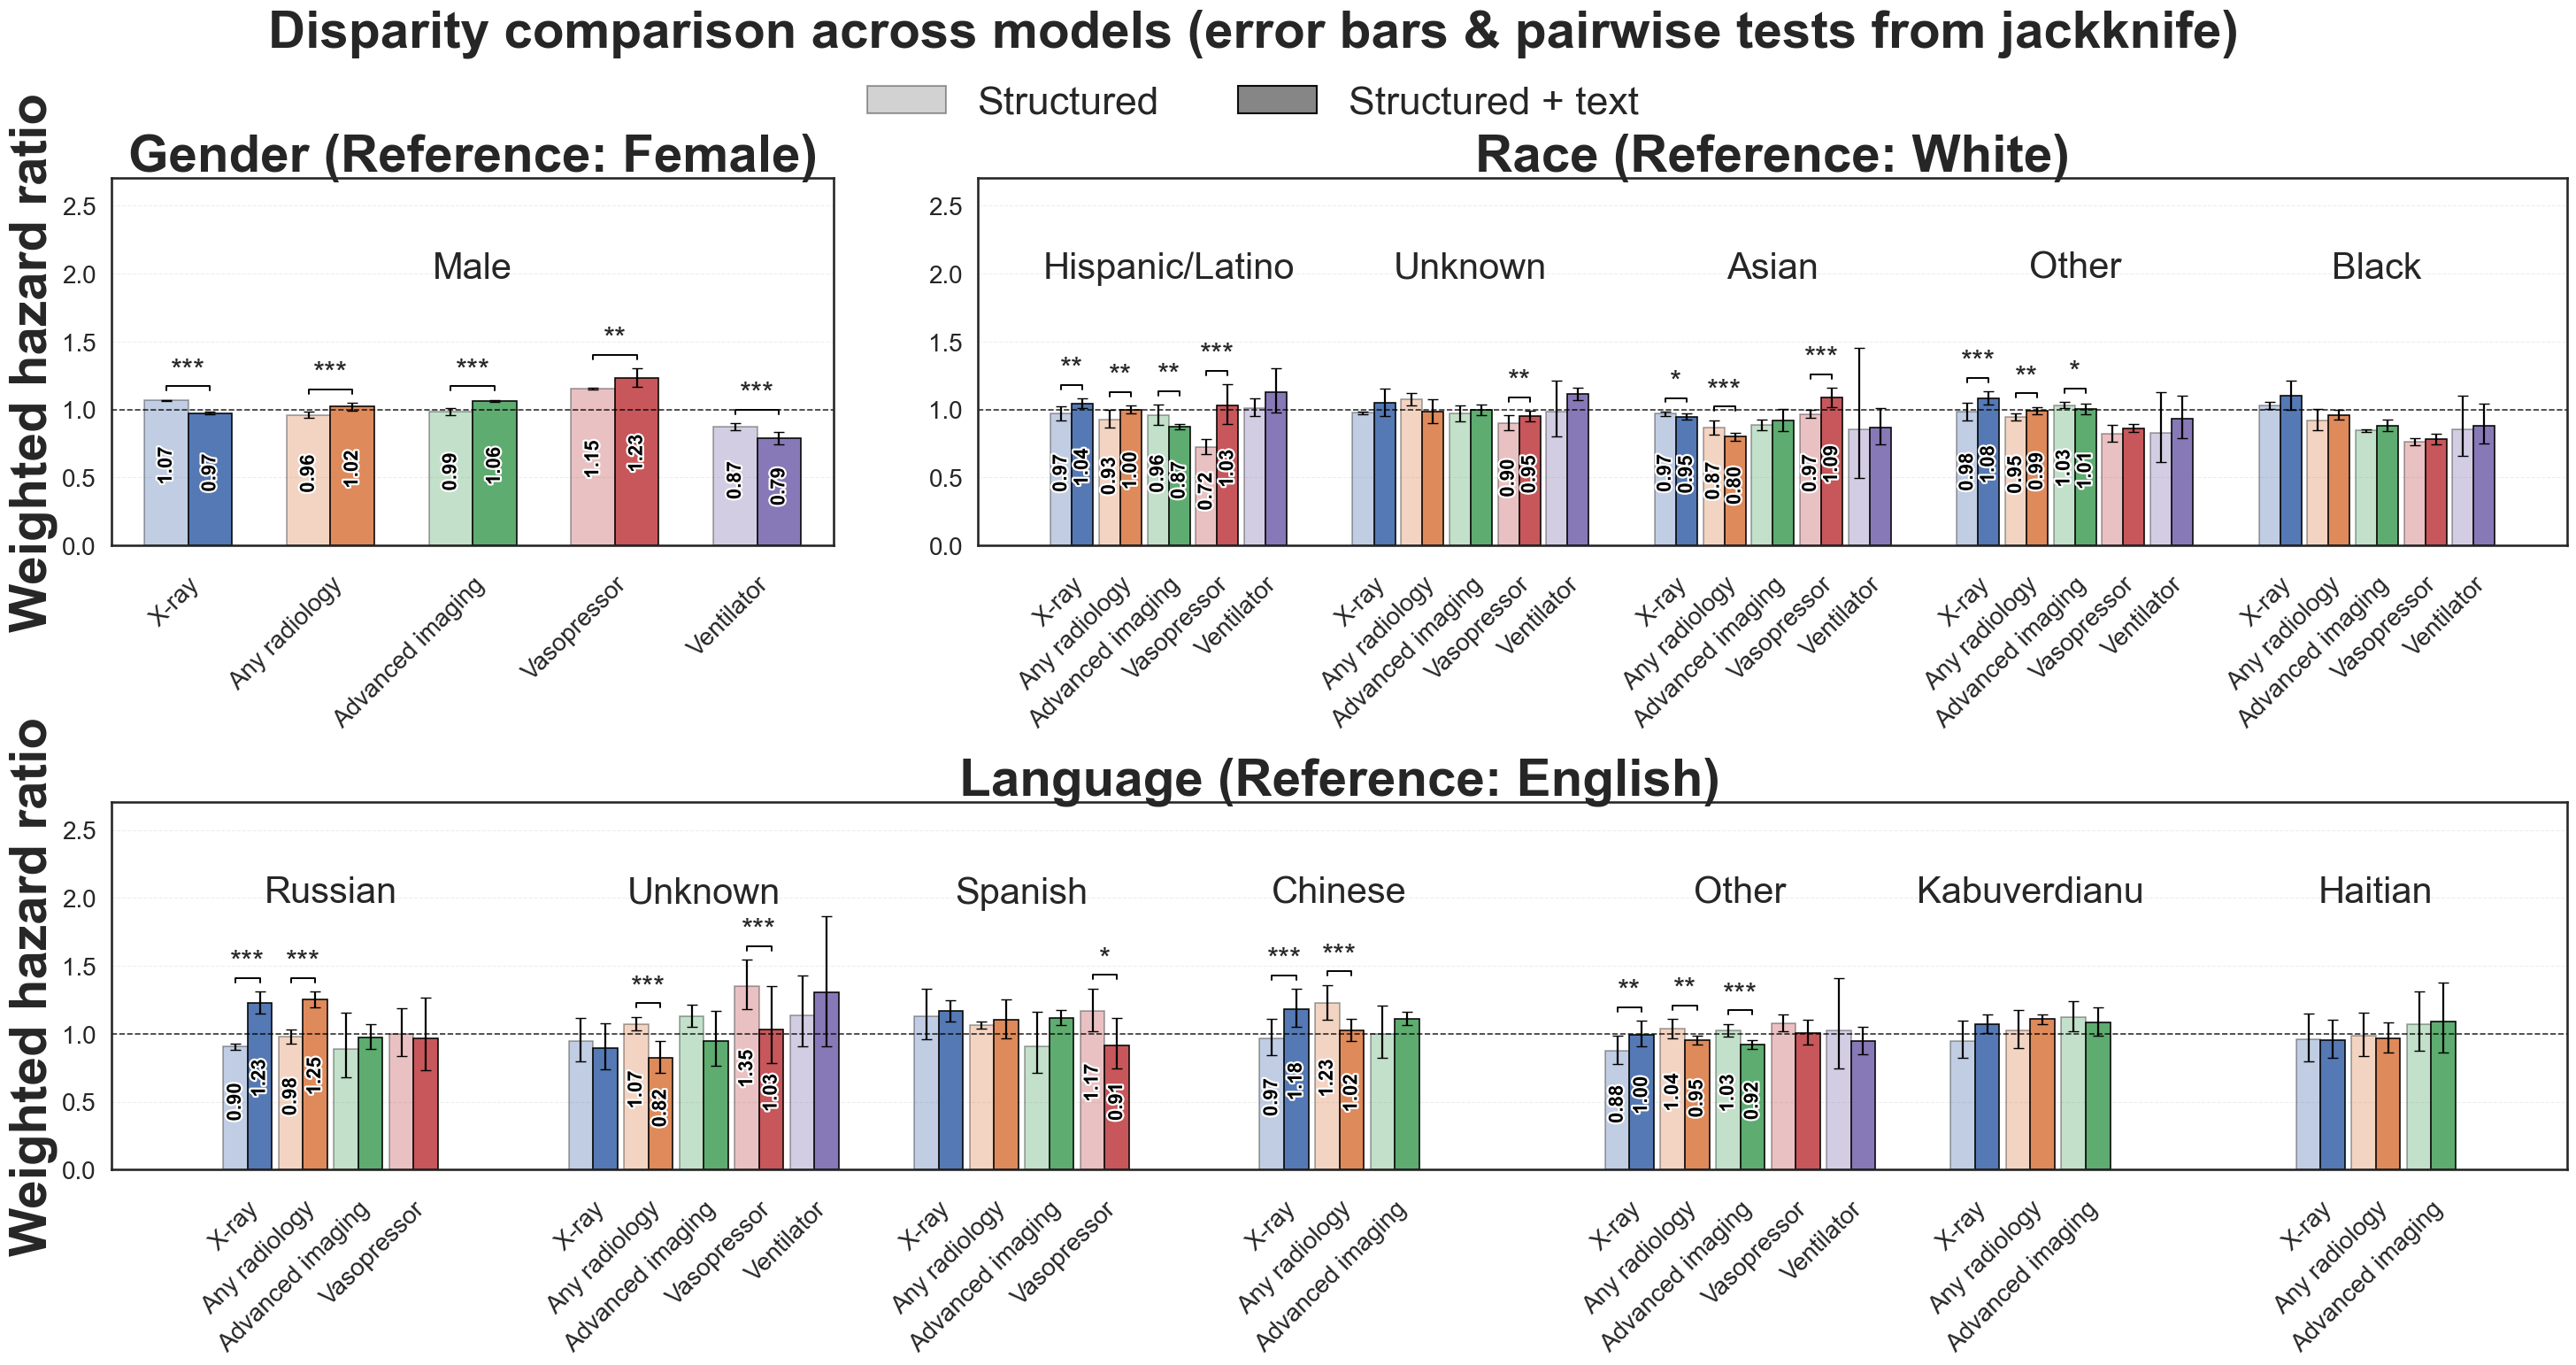

In [9]:
import matplotlib.patheffects as pe
from scipy.stats import norm

TITLE_FS = 42
LABEL_FS = 28
TICK_FS = 20
ANNO_FS = 24
TOPLABEL_FS = 26
BARLABEL_FS = 16

fig = plt.figure(figsize=(30, 16))
gs = GridSpec(2, 3, figure=fig)

gender_ax = fig.add_subplot(gs[0, 0])
race_ax = fig.add_subplot(gs[0, 1:3], sharey=gender_ax)
language_ax = fig.add_subplot(gs[1, 0:3], sharey=gender_ax)

# === FIXED SIGNIFICANCE FUNCTION ===
def p_to_stars_from_ci(delta_lo, delta_hi, ci=0.95):
    if pd.isna(delta_lo) or pd.isna(delta_hi):
        return ""

    z_crit = norm.ppf(1 - (1 - ci) / 2)
    se = (delta_hi - delta_lo) / (2 * z_crit)
    est = (delta_hi + delta_lo) / 2
    z = abs(est / se)
    p = 2 * (1 - norm.cdf(z))

    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

axes = {
    "gender": gender_ax,
    "race": race_ax,
    "language": language_ax,
}

fig.subplots_adjust(
    left=0.07,
    right=0.995,
    bottom=0.16,
    top=0.86,
    wspace=0.20,
    hspace=0.70,
)

spacing_cfg = {
    "gender": {"bar_w": 0.16, "outcome_gap": 0.52, "label_gap": 1.10},
    "race": {"bar_w": 0.22, "outcome_gap": 0.50, "label_gap": 0.62},
    "language": {"bar_w": 0.22, "outcome_gap": 0.50, "label_gap": 0.62},
}

ref_map = {
    "gender": "Female",
    "race": "White",
    "language": "English",
}

global_ymax = 0.0
for group_var in group_order:
    sub = plot_summ.loc[plot_summ["group_var"] == group_var]
    vals = []
    for col in ["hr_base_hi", "hr_text_hi"]:
        vals.extend(pd.to_numeric(sub[col], errors="coerce"))
    vals = [v for v in vals if pd.notna(v)]
    if vals:
        global_ymax = max(global_ymax, max(vals))

global_ymax *= 1.45
level_label_y = global_ymax * 0.8

text_effects = [
    pe.Stroke(linewidth=3.2, foreground="white"),
    pe.Normal(),
]

for group_var in group_order:
    ax = axes[group_var]
    sub = plot_summ.loc[plot_summ["group_var"] == group_var]

    bar_w = spacing_cfg[group_var]["bar_w"]
    outcome_gap = spacing_cfg[group_var]["outcome_gap"]
    label_gap = spacing_cfg[group_var]["label_gap"]

    term_order = (
        sub.groupby("term")["abs_delta_disp"]
        .max()
        .sort_values(ascending=False)
        .index.tolist()
    )

    xticks = []
    xticklabels = []
    level_centers = []
    level_labels = []

    x_cursor = 0.0

    for term in term_order:
        term_df = sub.loc[sub["term"] == term]
        outcome_positions_this_term = []

        for i_outcome, outcome in enumerate(outcomes):
            row_df = term_df.loc[term_df["outcome"] == outcome]
            if row_df.empty:
                continue

            row = row_df.iloc[0]
            c = outcome_to_color[outcome]

            x0 = x_cursor + i_outcome * outcome_gap
            x_base = x0 - bar_w / 2
            x_text = x0 + bar_w / 2

            base = float(row["hr_base"])
            text = float(row["hr_text"])

            base_lo = float(row["hr_base_lo"])
            base_hi = float(row["hr_base_hi"])
            text_lo = float(row["hr_text_lo"])
            text_hi = float(row["hr_text_hi"])

            ax.bar(x_base, base, width=bar_w, color=c, alpha=0.35,
                   edgecolor="black", linewidth=1.2, zorder=2)

            ax.bar(x_text, text, width=bar_w, color=c, alpha=0.95,
                   edgecolor="black", linewidth=1.2, zorder=2)

            ax.errorbar(
                x_base, base,
                yerr=[[base - base_lo], [base_hi - base]],
                fmt="none", ecolor="black",
                elinewidth=1.6, capsize=4, zorder=3
            )

            ax.errorbar(
                x_text, text,
                yerr=[[text - text_lo], [text_hi - text]],
                fmt="none", ecolor="black",
                elinewidth=1.6, capsize=4, zorder=3
            )

            stars = p_to_stars_from_ci(row["delta_lo"], row["delta_hi"])

            if stars:
                base_label_y = max(base * 0.55, 0.10)
                text_label_y = max(text * 0.55, 0.10)

                ax.text(x_base, base_label_y, f"{base:.2f}",
                        ha="center", va="center", rotation=90,
                        fontsize=BARLABEL_FS, fontweight="bold",
                        color="black", path_effects=text_effects, zorder=5)

                ax.text(x_text, text_label_y, f"{text:.2f}",
                        ha="center", va="center", rotation=90,
                        fontsize=BARLABEL_FS, fontweight="bold",
                        color="black", path_effects=text_effects, zorder=5)

                yb = max(base_hi, text_hi) + 0.025 * global_ymax
                h = 0.012 * global_ymax

                ax.plot([x_base, x_base, x_text, x_text],
                        [yb, yb + h, yb + h, yb],
                        color="black", linewidth=1.4, zorder=4)

                ax.text((x_base + x_text) / 2,
                        yb + h + 0.004 * global_ymax,
                        stars,
                        ha="center", va="bottom",
                        fontsize=ANNO_FS, zorder=5)

            xticks.append(x0)
            xticklabels.append(outcome_map[outcome])
            outcome_positions_this_term.append(x0)

        if outcome_positions_this_term:
            level_centers.append(np.mean(outcome_positions_this_term))
            level_labels.append(pretty_level_name(term, group_var))

        x_cursor += len(outcomes) * outcome_gap + label_gap

    ax.set_title(
        f"{group_title_map[group_var]} (Reference: {ref_map[group_var]})",
        fontsize=TITLE_FS,
        fontweight="bold",
    )

    ax.set_xticks(xticks)
    ax.set_xticklabels(
        xticklabels,
        rotation=45,
        ha="right",
        rotation_mode="anchor",
        fontsize=TICK_FS,
    )

    ax.tick_params(axis="x", length=0, pad=22)
    ax.tick_params(axis="y", labelsize=TICK_FS)

    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
    ax.set_axisbelow(True)
    ax.set_ylim(0, global_ymax)
    ax.axhline(1.0, linestyle="--", linewidth=1.2,
               color="black", alpha=0.8)

    for xpos, lbl in zip(level_centers, level_labels):
        ax.text(xpos, level_label_y, lbl,
                ha="center", va="top",
                fontsize=TOPLABEL_FS + 4)

gender_ax.set_ylabel("Weighted hazard ratio",
                     fontsize=TITLE_FS,
                     fontweight="bold")

language_ax.set_ylabel("Weighted hazard ratio",
                       fontsize=TITLE_FS,
                       fontweight="bold")

fig.suptitle(
    "Disparity comparison across models (error bars & pairwise tests from jackknife)",
    fontsize=TITLE_FS,
    fontweight="bold"
)



legend_model = [
    Patch(facecolor="gray", edgecolor="black", alpha=0.35, label="Structured"),
    Patch(facecolor="gray", edgecolor="black", alpha=0.95, label="Structured + text"),
]


fig.legend(handles=legend_model,
           loc="upper center",
            bbox_to_anchor=(0.5, 0.95),
           ncol=2,
           frameon=False,
           fontsize=32)

plt.savefig(OUTPUT_DIR / "dagj_plot.pdf",
            format="pdf",
            bbox_inches="tight")

plt.show()

In [10]:
table_rows = []

for group_var in group_order:
    sub = plot_summ.loc[plot_summ["group_var"] == group_var]

    term_order = (
        sub.groupby("term")["abs_delta_disp"]
        .max()
        .sort_values(ascending=False)
        .index.tolist()
    )

    for term in term_order:
        term_df = sub.loc[sub["term"] == term]

        for outcome in outcomes:
            row_df = term_df.loc[term_df["outcome"] == outcome]
            if row_df.empty:
                continue

            row = row_df.iloc[0]

            table_rows.append({
                "group_var": group_var,
                "level": pretty_level_name(term, group_var),
                "reference": ref_map[group_var],
                "outcome": outcome_map[outcome],
                "hr_base": row["hr_base"],
                "hr_base_lo": row["hr_base_lo"],
                "hr_base_hi": row["hr_base_hi"],
                "hr_text": row["hr_text"],
                "hr_text_lo": row["hr_text_lo"],
                "hr_text_hi": row["hr_text_hi"],
                "delta_est_from_ci": (row["delta_lo"] + row["delta_hi"]) / 2,
                "delta_lo": row["delta_lo"],
                "delta_hi": row["delta_hi"],
                "stars": p_to_stars_from_ci(row["delta_lo"], row["delta_hi"]),
            })

fig_table = pd.DataFrame(table_rows)

print(
    fig_table.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)

group_var           level reference          outcome  hr_base  hr_base_lo  hr_base_hi  hr_text  hr_text_lo  hr_text_hi  delta_est_from_ci  delta_lo  delta_hi stars
   gender            Male    Female            X-ray    1.069       1.066       1.072    0.973       0.964       0.983             -0.094    -0.102    -0.085   ***
   gender            Male    Female    Any radiology    0.959       0.936       0.983    1.020       0.994       1.048              0.062     0.036     0.088   ***
   gender            Male    Female Advanced imaging    0.985       0.962       1.009    1.063       1.054       1.072              0.076     0.059     0.094   ***
   gender            Male    Female      Vasopressor    1.152       1.147       1.158    1.234       1.169       1.301              0.068     0.017     0.119    **
   gender            Male    Female       Ventilator    0.873       0.846       0.900    0.788       0.746       0.832             -0.102    -0.150    -0.054   ***
     race Hispan

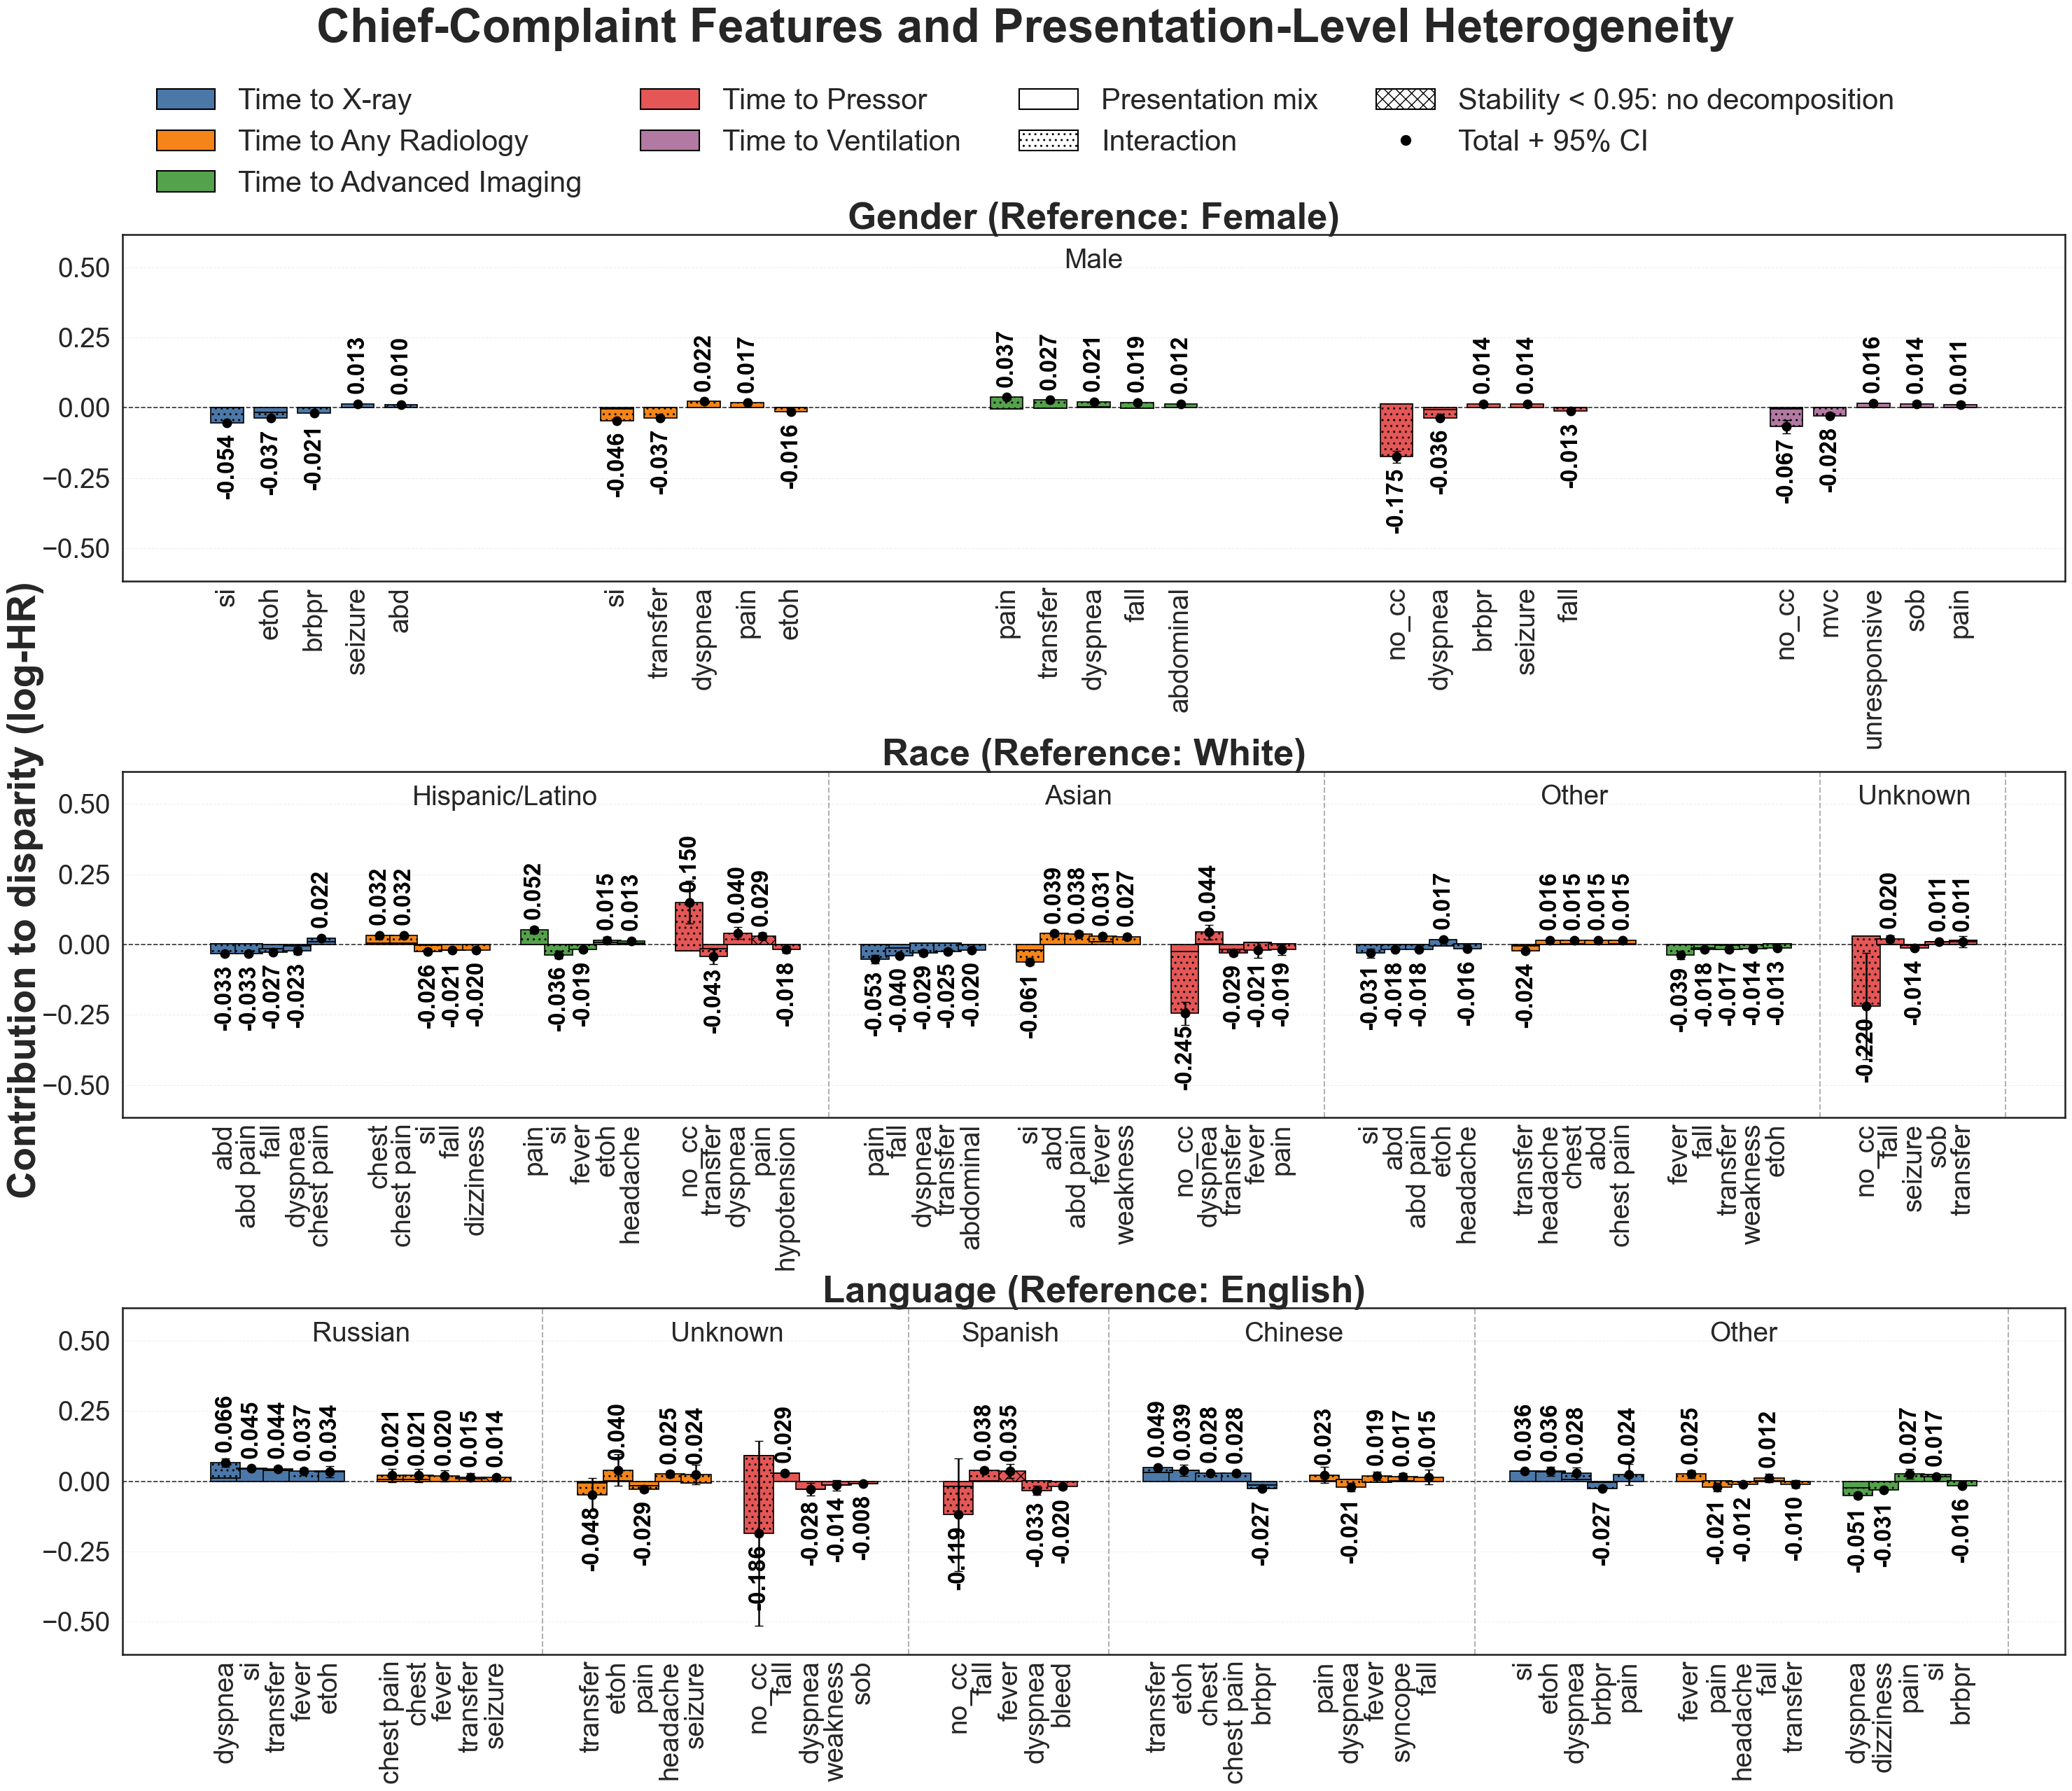

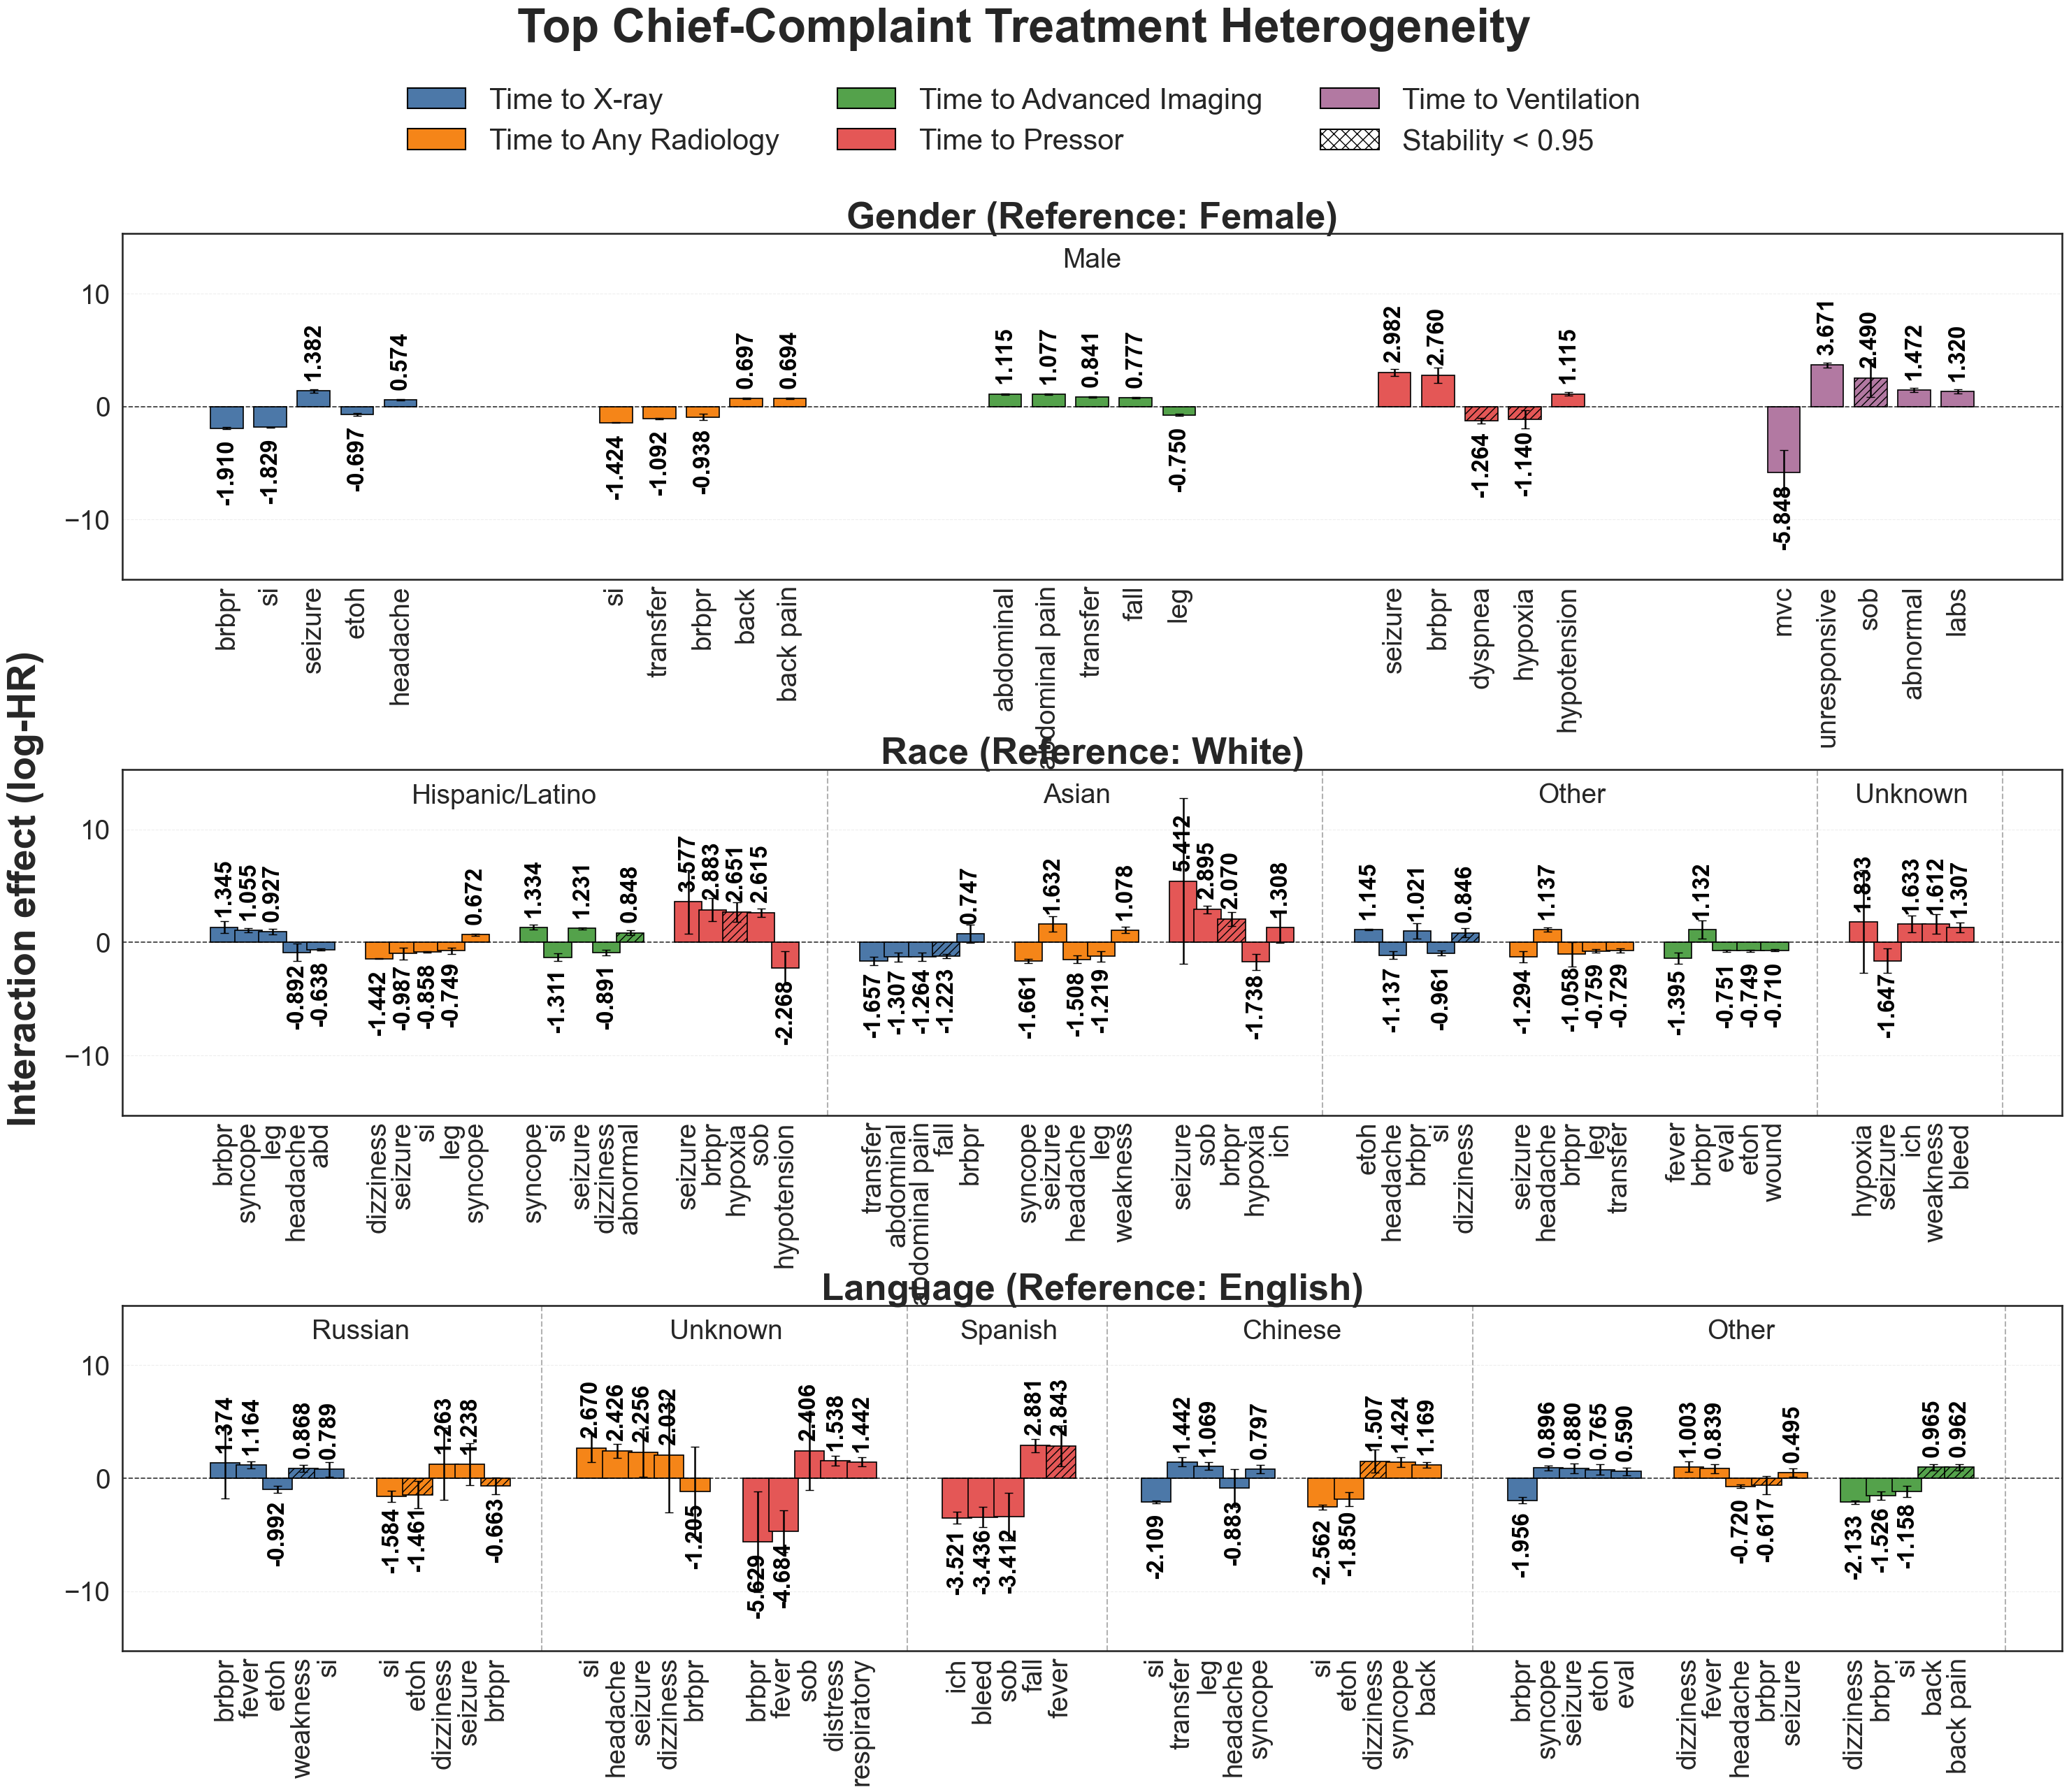

In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


TITLE_FS = 48
SUBTITLE_FS = 38
LABEL_FS = 28
TICK_FS = 28
ANNO_FS = 28
TOPLABEL_FS = 28
BARLABEL_FS = 24

DISPLAY_TOPN = 5
N_GROUPS = 10
STABILITY_THRESHOLD = 0.95

OUTCOME_ORDER = [
    "time_to_xray_hours",
    "time_to_any_rad_hours",
    "time_to_advanced_hours",
    "time_to_pressor_hours",
    "time_to_vent_hours",
]

OUTCOME_MAP = {
    "time_to_xray_hours": "Time to X-ray",
    "time_to_any_rad_hours": "Time to Any Radiology",
    "time_to_advanced_hours": "Time to Advanced Imaging",
    "time_to_pressor_hours": "Time to Pressor",
    "time_to_vent_hours": "Time to Ventilation",
}

GROUP_ORDER = ["gender", "race", "language"]

GROUP_TITLE_MAP = {
    "gender": "Gender",
    "race": "Race",
    "language": "Language",
}

REF_MAP = {
    "gender": "Female",
    "race": "White",
    "language": "English",
}

ROOT = Path(".")
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATASET_SPECS = [
    ("radiology", ROOT / "main" / "radiology" / "delete_a_group_jackknife"),
    ("pressor", ROOT / "main" / "icu" / "pressor" / "delete_a_group_jackknife"),
    ("vent", ROOT / "main" / "icu" / "vent" / "delete_a_group_jackknife"),
]

OUTCOME_TO_COLOR = {
    "time_to_xray_hours": "#4C78A8",
    "time_to_any_rad_hours": "#F58518",
    "time_to_advanced_hours": "#54A24B",
    "time_to_pressor_hours": "#E45756",
    "time_to_vent_hours": "#B279A2",
}

SPACING_CFG = {
    "gender": {"bar_w": 0.18, "keyword_gap": 0.24, "outcome_gap": 0.95, "label_gap": 1.40},
    "race": {"bar_w": 0.34, "keyword_gap": 0.30, "outcome_gap": 0.42, "label_gap": 0.38},
    "language": {"bar_w": 0.34, "keyword_gap": 0.30, "outcome_gap": 0.42, "label_gap": 0.38},
}


def pretty_term_name(x):
    if x.startswith("race_"):
        val = x[len("race_"):].replace("_", " ")
        return f"Race: {val}"
    if x.startswith("language_"):
        val = x[len("language_"):].replace("_", " ")
        return f"Language: {val}"
    if x.startswith("gender_"):
        val = x[len("gender_"):]
        if val == "M":
            val = "Male"
        elif val == "F":
            val = "Female"
        return f"Gender: {val}"
    return x.replace("_", " ").strip().title()


def split_group_and_level(term):
    term = str(term)
    for group_var in GROUP_ORDER:
        prefix = f"{group_var}_"
        if term.startswith(prefix):
            return group_var, term[len(prefix):]
    return None, term


def pretty_level_name(term, group_var):
    _, level = split_group_and_level(term)

    if group_var == "gender":
        if level == "M":
            return "Male"
        if level == "F":
            return "Female"

    return str(level).replace("_", " ").strip().title()


def load_dagj_pair(base_dir, dataset_name):
    summary = pd.read_parquet(base_dir / "jackknife_summary.parquet").copy()
    interaction = pd.read_parquet(base_dir / "jackknife_keyword_interaction_summary.parquet").copy()
    mix = pd.read_parquet(base_dir / "jackknife_keyword_mix_contribution_summary.parquet").copy()
    interaction_contribution = pd.read_parquet(base_dir / "jackknife_keyword_interaction_contribution_summary.parquet").copy()
    total = pd.read_parquet(base_dir / "jackknife_keyword_total_contribution_summary.parquet").copy()

    summary["dataset"] = dataset_name
    interaction["dataset"] = dataset_name
    mix["dataset"] = dataset_name
    interaction_contribution["dataset"] = dataset_name
    total["dataset"] = dataset_name
    return summary, interaction, mix, interaction_contribution, total


def load_all_inputs():
    summary_parts = []
    interaction_parts = []
    mix_parts = []
    interaction_contribution_parts = []
    total_parts = []

    for dataset_name, dagj_dir in DATASET_SPECS:
        summary_df, interaction_df, mix_df, interaction_contribution_df, total_df = load_dagj_pair(dagj_dir, dataset_name)
        summary_parts.append(summary_df)
        interaction_parts.append(interaction_df)
        mix_parts.append(mix_df)
        interaction_contribution_parts.append(interaction_contribution_df)
        total_parts.append(total_df)

    summary_all = pd.concat(summary_parts, ignore_index=True)
    interaction_all = pd.concat(interaction_parts, ignore_index=True)
    mix_all = pd.concat(mix_parts, ignore_index=True)
    interaction_contribution_all = pd.concat(interaction_contribution_parts, ignore_index=True)
    total_all = pd.concat(total_parts, ignore_index=True)
    return summary_all, interaction_all, mix_all, interaction_contribution_all, total_all


def get_sig_demo_hr_ratio_table_dagj(summary_all):
    summ = summary_all.copy()
    summ = summ.loc[summ["level"] != summ["ref_level"]].copy()

    summ["delta_beta"] = pd.to_numeric(summ["delta_beta"], errors="coerce")
    summ["abs_delta_beta"] = np.abs(summ["delta_beta"])
    summ["hr_ratio"] = np.exp(summ["delta_beta"])
    summ["hr_ratio_lo"] = np.exp(pd.to_numeric(summ["delta_beta_jackknife_ci_low"], errors="coerce"))
    summ["hr_ratio_hi"] = np.exp(pd.to_numeric(summ["delta_beta_jackknife_ci_high"], errors="coerce"))
    summ["sig_hr_ratio"] = (summ["hr_ratio_lo"] > 1.0) | (summ["hr_ratio_hi"] < 1.0)
    summ["demo_label"] = summ["term"].map(pretty_term_name)

    summ["outcome"] = pd.Categorical(summ["outcome"], categories=OUTCOME_ORDER, ordered=True)
    summ = (
        summ.loc[summ["sig_hr_ratio"]]
        .sort_values(["group_var", "abs_delta_beta", "outcome"], ascending=[True, False, True])
        .reset_index(drop=True)
    )
    return summ


def _resolve_stability_column(df, metric_col):
    candidates = [
        f"{metric_col}_rank_stability",
        "rank_stability",
        f"{metric_col}_selection_frequency_topk",
    ]
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(
        "Could not find a stability column. "
        f"Tried: {candidates}"
    )


def build_keyword_plot_table(
    summary_all,
    keyword_metric_all,
    metric_col,
    display_topn=5,
):
    sig_demo_df = get_sig_demo_hr_ratio_table_dagj(summary_all)
    km = keyword_metric_all.copy()

    km[metric_col] = pd.to_numeric(km[metric_col], errors="coerce")
    km[f"{metric_col}_jackknife_ci_low"] = pd.to_numeric(km[f"{metric_col}_jackknife_ci_low"], errors="coerce")
    km[f"{metric_col}_jackknife_ci_high"] = pd.to_numeric(km[f"{metric_col}_jackknife_ci_high"], errors="coerce")

    stability_col = _resolve_stability_column(km, metric_col)
    km[stability_col] = pd.to_numeric(km[stability_col], errors="coerce")

    rows = []

    for meta in sig_demo_df.itertuples(index=False):
        group_var, level = split_group_and_level(meta.term)

        sub = km.loc[
            (km["dataset"] == meta.dataset)
            & (km["outcome"] == meta.outcome)
            & (km["group_var"] == group_var)
            & (km["level"] == level)
            & (km["ref_level"] == meta.ref_level)
            & (km["term"] == meta.term)
        ].copy()

        if len(sub) == 0:
            continue

        sub["abs_metric"] = sub[metric_col].abs()
        sub = sub.sort_values(
            ["abs_metric", stability_col, "token"],
            ascending=[False, False, True],
        ).reset_index(drop=True)

        keep = sub.head(display_topn).copy()

        for rank, row in enumerate(keep.itertuples(index=False), start=1):
            stability_value = float(getattr(row, stability_col))

            rows.append(
                {
                    "dataset": meta.dataset,
                    "outcome": meta.outcome,
                    "outcome_label": OUTCOME_MAP.get(meta.outcome, meta.outcome),
                    "demo_var": meta.term,
                    "demo_label": pretty_term_name(meta.term),
                    "group_var": group_var,
                    "level": level,
                    "hr_ratio": float(meta.hr_ratio),
                    "hr_ratio_lo": float(meta.hr_ratio_lo),
                    "hr_ratio_hi": float(meta.hr_ratio_hi),
                    "delta_beta": float(meta.delta_beta),
                    "abs_delta_beta": float(meta.abs_delta_beta),
                    "keyword_rank_total": int(rank),
                    "token": str(row.token),
                    "metric_value": float(getattr(row, metric_col)),
                    "metric_ci_low": float(getattr(row, f"{metric_col}_jackknife_ci_low")),
                    "metric_ci_high": float(getattr(row, f"{metric_col}_jackknife_ci_high")),
                    "stability_value": stability_value,
                    "is_stable": bool(stability_value >= STABILITY_THRESHOLD),
                }
            )

    plot_df = pd.DataFrame(rows)
    if len(plot_df) == 0:
        return sig_demo_df, plot_df

    plot_df["outcome"] = pd.Categorical(plot_df["outcome"], categories=OUTCOME_ORDER, ordered=True)
    plot_df = plot_df.sort_values(
        ["group_var", "abs_delta_beta", "demo_var", "outcome", "keyword_rank_total"],
        ascending=[True, False, True, True, True],
    ).reset_index(drop=True)

    return sig_demo_df, plot_df


def build_decomposition_plot_table(
    summary_all,
    mix_all,
    interaction_contribution_all,
    total_all,
    display_topn=5,
):
    sig_demo_df = get_sig_demo_hr_ratio_table_dagj(summary_all)

    mix_all = mix_all.copy()
    interaction_contribution_all = interaction_contribution_all.copy()
    total_all = total_all.copy()

    mix_all["mix_contribution"] = pd.to_numeric(mix_all["mix_contribution"], errors="coerce")
    interaction_contribution_all["interaction_contribution"] = pd.to_numeric(
        interaction_contribution_all["interaction_contribution"], errors="coerce"
    )
    total_all["total_contribution"] = pd.to_numeric(total_all["total_contribution"], errors="coerce")
    total_all["total_contribution_jackknife_ci_low"] = pd.to_numeric(
        total_all["total_contribution_jackknife_ci_low"], errors="coerce"
    )
    total_all["total_contribution_jackknife_ci_high"] = pd.to_numeric(
        total_all["total_contribution_jackknife_ci_high"], errors="coerce"
    )

    stability_col = _resolve_stability_column(total_all, "total_contribution")
    total_all[stability_col] = pd.to_numeric(total_all[stability_col], errors="coerce")

    rows = []

    for meta in sig_demo_df.itertuples(index=False):
        group_var, level = split_group_and_level(meta.term)

        total_sub = total_all.loc[
            (total_all["dataset"] == meta.dataset)
            & (total_all["outcome"] == meta.outcome)
            & (total_all["group_var"] == group_var)
            & (total_all["level"] == level)
            & (total_all["ref_level"] == meta.ref_level)
            & (total_all["term"] == meta.term)
        ].copy()

        if len(total_sub) == 0:
            continue

        mix_sub = mix_all.loc[
            (mix_all["dataset"] == meta.dataset)
            & (mix_all["outcome"] == meta.outcome)
            & (mix_all["group_var"] == group_var)
            & (mix_all["level"] == level)
            & (mix_all["ref_level"] == meta.ref_level)
            & (mix_all["term"] == meta.term)
        ][["token", "mix_contribution"]].copy()

        int_sub = interaction_contribution_all.loc[
            (interaction_contribution_all["dataset"] == meta.dataset)
            & (interaction_contribution_all["outcome"] == meta.outcome)
            & (interaction_contribution_all["group_var"] == group_var)
            & (interaction_contribution_all["level"] == level)
            & (interaction_contribution_all["ref_level"] == meta.ref_level)
            & (interaction_contribution_all["term"] == meta.term)
        ][["token", "interaction_contribution"]].copy()

        sub = total_sub.merge(mix_sub, on="token", how="left")
        sub = sub.merge(int_sub, on="token", how="left")

        sub["abs_metric"] = sub["total_contribution"].abs()
        sub = sub.sort_values(
            ["abs_metric", stability_col, "token"],
            ascending=[False, False, True],
        ).reset_index(drop=True)

        keep = sub.head(display_topn).copy()

        for rank, row in enumerate(keep.itertuples(index=False), start=1):
            stability_value = float(getattr(row, stability_col))

            rows.append(
                {
                    "dataset": meta.dataset,
                    "outcome": meta.outcome,
                    "outcome_label": OUTCOME_MAP.get(meta.outcome, meta.outcome),
                    "demo_var": meta.term,
                    "demo_label": pretty_term_name(meta.term),
                    "group_var": group_var,
                    "level": level,
                    "hr_ratio": float(meta.hr_ratio),
                    "hr_ratio_lo": float(meta.hr_ratio_lo),
                    "hr_ratio_hi": float(meta.hr_ratio_hi),
                    "delta_beta": float(meta.delta_beta),
                    "abs_delta_beta": float(meta.abs_delta_beta),
                    "keyword_rank_total": int(rank),
                    "token": str(row.token),
                    "mix_value": float(row.mix_contribution),
                    "interaction_value": float(row.interaction_contribution),
                    "total_value": float(row.total_contribution),
                    "total_ci_low": float(row.total_contribution_jackknife_ci_low),
                    "total_ci_high": float(row.total_contribution_jackknife_ci_high),
                    "stability_value": stability_value,
                    "is_stable": bool(stability_value >= STABILITY_THRESHOLD),
                }
            )

    plot_df = pd.DataFrame(rows)
    if len(plot_df) == 0:
        return sig_demo_df, plot_df

    plot_df["outcome"] = pd.Categorical(plot_df["outcome"], categories=OUTCOME_ORDER, ordered=True)
    plot_df = plot_df.sort_values(
        ["group_var", "abs_delta_beta", "demo_var", "outcome", "keyword_rank_total"],
        ascending=[True, False, True, True, True],
    ).reset_index(drop=True)

    return sig_demo_df, plot_df


def _compute_global_ylim(keyword_plot_df):
    vals = []
    for col in ["metric_value", "metric_ci_low", "metric_ci_high"]:
        x = pd.to_numeric(keyword_plot_df[col], errors="coerce").to_numpy(dtype=float)
        vals.extend(x[np.isfinite(x)].tolist())

    if len(vals) == 0:
        return (-1.0, 1.0)

    lo = min(vals)
    hi = max(vals)
    span = max(abs(lo), abs(hi))
    span = max(span, 1e-6)
    return (-1.20 * span, 1.20 * span)


def _compute_global_ylim_decomposition(plot_df):
    vals = []
    for col in ["mix_value", "interaction_value", "total_value", "total_ci_low", "total_ci_high"]:
        x = pd.to_numeric(plot_df[col], errors="coerce").to_numpy(dtype=float)
        vals.extend(x[np.isfinite(x)].tolist())

    if len(vals) == 0:
        return (-1.0, 1.0)

    lo = min(vals)
    hi = max(vals)
    span = max(abs(lo), abs(hi))
    span = max(span, 1e-6)
    return (-1.20 * span, 1.20 * span)


def plot_top_keywords_grouped_barplot(
    keyword_plot_df,
    fig_title,
    y_label,
    save_path
):
    fig = plt.figure(figsize=(30, 26))
    gs = GridSpec(3, 1, figure=fig)

    gender_ax = fig.add_subplot(gs[0, 0])
    race_ax = fig.add_subplot(gs[1, 0], sharey=gender_ax)
    language_ax = fig.add_subplot(gs[2, 0], sharey=gender_ax)

    axes = {
        "gender": gender_ax,
        "race": race_ax,
        "language": language_ax,
    }

    fig.subplots_adjust(
        left=0.07,
        right=0.995,
        bottom=0.08,
        top=0.86,
        hspace=0.55,
    )

    ymin, ymax = _compute_global_ylim(keyword_plot_df)
    level_label_y = ymax * 0.92 if ymax > 0 else 0.0

    for group_var in GROUP_ORDER:
        ax = axes[group_var]
        sub = keyword_plot_df.loc[keyword_plot_df["group_var"] == group_var].copy()

        bar_w = SPACING_CFG[group_var]["bar_w"]
        keyword_gap = SPACING_CFG[group_var]["keyword_gap"]
        outcome_gap = SPACING_CFG[group_var]["outcome_gap"]
        label_gap = SPACING_CFG[group_var]["label_gap"]

        term_order = (
            sub.groupby("demo_var")["abs_delta_beta"]
            .max()
            .sort_values(ascending=False)
            .index.tolist()
        )

        xticks = []
        xticklabels = []
        level_centers = []
        x_cursor = 0.0

        for term in term_order:
            term_df = sub.loc[sub["demo_var"] == term].copy()
            outcome_positions_this_term = []

            for outcome in OUTCOME_ORDER:
                out_df = (
                    term_df.loc[term_df["outcome"] == outcome]
                    .sort_values("keyword_rank_total", ascending=True)
                    .copy()
                )

                if len(out_df) == 0:
                    continue

                keyword_positions = []

                for i, row in enumerate(out_df.itertuples(index=False)):
                    x = x_cursor + i * keyword_gap
                    y = float(row.metric_value)
                    y_lo = float(row.metric_ci_low)
                    y_hi = float(row.metric_ci_high)

                    hatch = None if row.is_stable else "///"

                    ax.bar(
                        x,
                        y,
                        width=bar_w,
                        color=OUTCOME_TO_COLOR[outcome],
                        edgecolor="black",
                        linewidth=1.2,
                        hatch=hatch,
                        zorder=2,
                    )

                    ax.errorbar(
                        x,
                        y,
                        yerr=[[y - y_lo], [y_hi - y]],
                        fmt="none",
                        ecolor="black",
                        elinewidth=1.8,
                        capsize=4,
                        zorder=3,
                    )

                    label_y = y + 0.03 * (ymax - ymin) if y >= 0 else y - 0.03 * (ymax - ymin)
                    va = "bottom" if y >= 0 else "top"

                    ax.text(
                        x,
                        label_y,
                        f"{y:.3f}",
                        ha="center",
                        va=va,
                        rotation=90,
                        fontsize=BARLABEL_FS,
                        fontweight="bold",
                        color="black",
                        zorder=4,
                    )

                    xticks.append(x)
                    xticklabels.append(str(row.token))
                    keyword_positions.append(x)

                outcome_positions_this_term.append(float(np.mean(keyword_positions)))
                x_cursor += len(out_df) * keyword_gap + outcome_gap

            if outcome_positions_this_term:
                level_centers.append(
                    (float(np.mean(outcome_positions_this_term)), pretty_level_name(term, group_var))
                )
            if group_var in ["race", "language"]:
                ax.axvline(
                    x_cursor - label_gap / 2,
                    linestyle="--",
                    linewidth=1.5,
                    color="black",
                    alpha=0.3,
                    zorder=1,
                )
            x_cursor += label_gap

        ax.set_title(
            f"{GROUP_TITLE_MAP[group_var]} (Reference: {REF_MAP[group_var]})",
            fontsize=SUBTITLE_FS,
            fontweight="bold",
            pad=6,
        )

        ax.set_xticks(xticks)
        ax.set_xticklabels(
            xticklabels,
            rotation=90,
            ha="center",
            fontsize=TICK_FS,
        )

        ax.tick_params(axis="x", length=0, pad=6)
        ax.tick_params(axis="y", labelsize=TICK_FS)
        ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
        ax.set_axisbelow(True)
        ax.set_ylim(ymin, ymax)
        ax.axhline(0.0, linestyle="--", linewidth=1.2, color="black", alpha=0.8)

        for xpos, lbl in level_centers:
            if group_var == "language" and lbl.lower() == "kabuverdianu":
                y_pos = ymin + 0.08
                va = "bottom"
            else:
                y_pos = level_label_y
                va = "top"

            ax.text(
                xpos,
                y_pos,
                lbl,
                ha="center",
                va=va,
                fontsize=TOPLABEL_FS,
            )

    fig.suptitle(
        fig_title,
        fontsize=TITLE_FS,
        fontweight="bold",
        y=0.985,
    )

    fig.text(
        0.015,
        0.5,
        y_label,
        va="center",
        rotation="vertical",
        fontsize=TITLE_FS - 8,
        fontweight="bold",
    )

    legend_model = [
        Patch(facecolor=OUTCOME_TO_COLOR[o], edgecolor="black", label=OUTCOME_MAP[o])
        for o in OUTCOME_ORDER
    ]
    legend_stability = Patch(
        facecolor="white",
        edgecolor="black",
        hatch="xx",
        label=f"Stability < {STABILITY_THRESHOLD:.2f}",
    )

    fig.legend(
        handles=legend_model + [legend_stability],
        loc="upper center",
        bbox_to_anchor=(0.5, 0.955),
        ncol=3,
        frameon=False,
        fontsize=30,
    )
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()


def plot_top_keywords_decomposition_grouped_barplot(
    keyword_plot_df,
    fig_title,
    y_label,
    save_path,
):
    fig = plt.figure(figsize=(30, 26))
    gs = GridSpec(3, 1, figure=fig)

    gender_ax = fig.add_subplot(gs[0, 0])
    race_ax = fig.add_subplot(gs[1, 0], sharey=gender_ax)
    language_ax = fig.add_subplot(gs[2, 0], sharey=gender_ax)

    axes = {
        "gender": gender_ax,
        "race": race_ax,
        "language": language_ax,
    }

    fig.subplots_adjust(
        left=0.07,
        right=0.995,
        bottom=0.08,
        top=0.86,
        hspace=0.55,
    )

    ymin, ymax = _compute_global_ylim_decomposition(keyword_plot_df)
    level_label_y = ymax * 0.92 if ymax > 0 else 0.0

    for group_var in GROUP_ORDER:
        ax = axes[group_var]
        sub = keyword_plot_df.loc[keyword_plot_df["group_var"] == group_var].copy()

        bar_w = SPACING_CFG[group_var]["bar_w"]
        keyword_gap = SPACING_CFG[group_var]["keyword_gap"]
        outcome_gap = SPACING_CFG[group_var]["outcome_gap"]
        label_gap = SPACING_CFG[group_var]["label_gap"]

        term_order = (
            sub.groupby("demo_var")["abs_delta_beta"]
            .max()
            .sort_values(ascending=False)
            .index.tolist()
        )

        xticks = []
        xticklabels = []
        level_centers = []
        x_cursor = 0.0

        for term in term_order:
            term_df = sub.loc[sub["demo_var"] == term].copy()
            outcome_positions_this_term = []

            for outcome in OUTCOME_ORDER:
                out_df = (
                    term_df.loc[term_df["outcome"] == outcome]
                    .sort_values("keyword_rank_total", ascending=True)
                    .copy()
                )

                if len(out_df) == 0:
                    continue

                keyword_positions = []

                for i, row in enumerate(out_df.itertuples(index=False)):
                    x = x_cursor + i * keyword_gap

                    y_mix = float(row.mix_value)
                    y_int = float(row.interaction_value)
                    y_total = float(row.total_value)
                    y_lo = float(row.total_ci_low)
                    y_hi = float(row.total_ci_high)

                    color = OUTCOME_TO_COLOR[outcome]

                    if row.is_stable:
                        ax.bar(
                            x,
                            y_mix,
                            bottom=0.0,
                            width=bar_w,
                            color=color,
                            edgecolor="black",
                            linewidth=1.2,
                            hatch=None,
                            zorder=2,
                        )

                        ax.bar(
                            x,
                            y_int,
                            bottom=y_mix,
                            width=bar_w,
                            color=color,
                            edgecolor="black",
                            linewidth=1.2,
                            hatch="..",
                            zorder=3,
                        )
                    else:
                        ax.bar(
                            x,
                            y_total,
                            bottom=0.0,
                            width=bar_w,
                            color=color,
                            edgecolor="black",
                            linewidth=1.2,
                            hatch="xx",
                            zorder=2,
                        )

                    ax.errorbar(
                        x,
                        y_total,
                        yerr=[[y_total - y_lo], [y_hi - y_total]],
                        fmt="o",
                        color="black",
                        elinewidth=1.8,
                        capsize=4,
                        zorder=4,
                    )

                    label_y = y_total + 0.03 * (ymax - ymin) if y_total >= 0 else y_total - 0.03 * (ymax - ymin)
                    va = "bottom" if y_total >= 0 else "top"

                    ax.text(
                        x,
                        label_y,
                        f"{y_total:.3f}",
                        ha="center",
                        va=va,
                        rotation=90,
                        fontsize=BARLABEL_FS,
                        fontweight="bold",
                        color="black",
                        zorder=5,
                    )

                    xticks.append(x)
                    xticklabels.append(str(row.token))
                    keyword_positions.append(x)

                outcome_positions_this_term.append(float(np.mean(keyword_positions)))
                x_cursor += len(out_df) * keyword_gap + outcome_gap

            if outcome_positions_this_term:
                level_centers.append(
                    (float(np.mean(outcome_positions_this_term)), pretty_level_name(term, group_var))
                )
            if group_var in ["race", "language"]:
                ax.axvline(
                    x_cursor - label_gap / 2,
                    linestyle="--",
                    linewidth=1.5,
                    color="black",
                    alpha=0.3,
                    zorder=1,
                )
            x_cursor += label_gap

        ax.set_title(
            f"{GROUP_TITLE_MAP[group_var]} (Reference: {REF_MAP[group_var]})",
            fontsize=SUBTITLE_FS,
            fontweight="bold",
            pad=6,
        )

        ax.set_xticks(xticks)
        ax.set_xticklabels(
            xticklabels,
            rotation=90,
            ha="center",
            fontsize=TICK_FS,
        )

        ax.tick_params(axis="x", length=0, pad=6)
        ax.tick_params(axis="y", labelsize=TICK_FS)
        ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
        ax.set_axisbelow(True)
        ax.set_ylim(ymin, ymax)
        ax.axhline(0.0, linestyle="--", linewidth=1.2, color="black", alpha=0.8)

        for xpos, lbl in level_centers:
            if group_var == "language" and lbl.lower() == "kabuverdianu":
                y_pos = ymin + 0.08
                va = "bottom"
            else:
                y_pos = level_label_y
                va = "top"

            ax.text(
                xpos,
                y_pos,
                lbl,
                ha="center",
                va=va,
                fontsize=TOPLABEL_FS,
            )

    fig.suptitle(
        fig_title,
        fontsize=TITLE_FS,
        fontweight="bold",
        y=0.985,
    )

    fig.text(
        0.015,
        0.5,
        y_label,
        va="center",
        rotation="vertical",
        fontsize=TITLE_FS - 8,
        fontweight="bold",
    )

    legend_outcome = [
        Patch(facecolor=OUTCOME_TO_COLOR[o], edgecolor="black", label=OUTCOME_MAP[o])
        for o in OUTCOME_ORDER
    ]
    legend_decomp = [
        Patch(facecolor="white", edgecolor="black", label="Presentation mix"),
        Patch(facecolor="white", edgecolor="black", hatch="..", label="Interaction"),
        Patch(facecolor="white", edgecolor="black", hatch="xx", label=f"Stability < {STABILITY_THRESHOLD:.2f}: no decomposition"),
        Line2D([0], [0], color="black", marker="o", linestyle="None", markersize=10, label="Total + 95% CI"),
    ]

    fig.legend(
        handles=legend_outcome + legend_decomp,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.955),
        ncol=4,
        frameon=False,
        fontsize=30,
    )

    plt.savefig(save_path, bbox_inches="tight")
    plt.show()


summary_all, interaction_all, mix_all, interaction_contribution_all, total_all = load_all_inputs()

sig_demo_df, decomposition_plot_df = build_decomposition_plot_table(
    summary_all=summary_all,
    mix_all=mix_all,
    interaction_contribution_all=interaction_contribution_all,
    total_all=total_all,
    display_topn=DISPLAY_TOPN,
)

_, interaction_plot_df = build_keyword_plot_table(
    summary_all=summary_all,
    keyword_metric_all=interaction_all,
    metric_col="interaction_score",
    display_topn=DISPLAY_TOPN,
)

plot_top_keywords_decomposition_grouped_barplot(
    keyword_plot_df=decomposition_plot_df,
    fig_title="Chief-Complaint Features and Presentation-Level Heterogeneity",
    y_label="Contribution to disparity (log-HR)",
    save_path="./figures/top_cc_decomposition.pdf",
)

plot_top_keywords_grouped_barplot(
    keyword_plot_df=interaction_plot_df,
    fig_title="Top Chief-Complaint Treatment Heterogeneity",
    y_label="Interaction effect (log-HR)",
    save_path="./figures/top_cc_interaction.pdf",
)

In [12]:
decomposition_table = decomposition_plot_df[
    [
        "group_var",
        "demo_label",
        "outcome_label",
        "keyword_rank_total",
        "token",
        "mix_value",
        "interaction_value",
        "total_value",
        "total_ci_low",
        "total_ci_high",
        "stability_value",
        "is_stable",
        "hr_ratio",
        "hr_ratio_lo",
        "hr_ratio_hi",
        "delta_beta",
    ]
].copy()

print(
    decomposition_table.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)

group_var            demo_label            outcome_label  keyword_rank_total        token  mix_value  interaction_value  total_value  total_ci_low  total_ci_high  stability_value  is_stable  hr_ratio  hr_ratio_lo  hr_ratio_hi  delta_beta
   gender          Gender: Male      Time to Ventilation                   1        no_cc     -0.005             -0.062       -0.067        -0.091         -0.043            1.000       True     0.903        0.861        0.947      -0.102
   gender          Gender: Male      Time to Ventilation                   2          mvc      0.001             -0.030       -0.028        -0.036         -0.020            1.000       True     0.903        0.861        0.947      -0.102
   gender          Gender: Male      Time to Ventilation                   3 unresponsive      0.001              0.016        0.016         0.015          0.018            1.000       True     0.903        0.861        0.947      -0.102
   gender          Gender: Male      Time to Ven